In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import colorsys
import hashlib
import pickle
import random
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display as display_figure
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from abstractgraph.operators import *
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator, edge_neighbors


In [3]:
# Copied/adapted from ControlFlowGraphsForMalware/src/cic_sgg/visualization.py.
MAX_LAYOUT_NODES = 450
ROLE_MARKERS = {"entry": "s", "exit": "D", "internal": "o"}


def cfg_layout(graph: nx.DiGraph, random_seed: int = 1337):
    try:
        return nx.nx_pydot.graphviz_layout(graph, prog="dot")
    except Exception:
        return nx.spring_layout(graph, seed=random_seed)


def mnemonic_label(attrs):
    mnemonic = attrs.get("mnemonic") or attrs.get("label")
    if mnemonic:
        return str(mnemonic)
    node_label = attrs.get("node_label")
    if node_label and ":" in str(node_label):
        return str(node_label).split(":", 1)[1]
    return "unknown"


@lru_cache(maxsize=None)
def mnemonic_color(mnemonic: str | None) -> str:
    if not mnemonic or mnemonic == "unknown":
        return "#9d9d9d"
    digest = hashlib.md5(mnemonic.encode("utf-8")).hexdigest()
    hue = int(digest[:8], 16) / 0xFFFFFFFF
    red, green, blue = colorsys.hsv_to_rgb(hue, 0.62, 0.82)
    return f"#{round(red * 255):02x}{round(green * 255):02x}{round(blue * 255):02x}"


def node_role(attrs) -> str:
    role = attrs.get("node_role")
    if role in ROLE_MARKERS:
        return str(role)
    if attrs.get("is_entry"):
        return "entry"
    if attrs.get("is_exit"):
        return "exit"
    return "internal"


def draw_cfg_graph(
    graph: nx.DiGraph,
    ax: plt.Axes,
    random_seed: int = 1337,
    max_layout_nodes: int = MAX_LAYOUT_NODES,
) -> nx.DiGraph:
    """Draw a directed CFG-like NetworkX graph with nodes colored by mnemonic."""
    if graph.number_of_nodes() > max_layout_nodes:
        graph = graph.subgraph(list(graph.nodes())[:max_layout_nodes]).copy()
    pos = cfg_layout(graph, random_seed=random_seed)
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        arrows=True,
        arrowsize=8,
        width=0.8,
        alpha=0.55,
        edge_color="#444444",
        connectionstyle="arc3,rad=0.06",
    )
    for role, marker in ROLE_MARKERS.items():
        nodes = [node for node, attrs in graph.nodes(data=True) if node_role(attrs) == role]
        if not nodes:
            continue
        node_colors = [mnemonic_color(mnemonic_label(graph.nodes[node])) for node in nodes]
        nx.draw_networkx_nodes(
            graph,
            pos,
            nodelist=nodes,
            ax=ax,
            node_size=58 if role != "internal" else 45,
            node_color=node_colors,
            node_shape=marker,
            linewidths=0.45,
            edgecolors="white",
        )
    ax.axis("off")
    return graph


def display_graphs(
    graphs,
    *,
    n_graphs_per_line: int = 5,
    random_seed: int = 1337,
    figsize_per_graph: tuple[float, float] = (4, 4),
    max_layout_nodes: int = MAX_LAYOUT_NODES,
    titles=None,
    **_,
):
    graphs = list(graphs)
    if not graphs:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.text(0.5, 0.5, "No graphs to draw", ha="center", va="center")
        ax.axis("off")
        display_figure(fig)
        plt.close(fig)
        return fig

    cols = max(1, min(int(n_graphs_per_line), len(graphs)))
    rows = (len(graphs) + cols - 1) // cols
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_per_graph[0] * cols, figsize_per_graph[1] * rows),
    )
    axes_list = list(axes.flat) if hasattr(axes, "flat") else [axes]
    for i, (ax, graph) in enumerate(zip(axes_list, graphs)):
        drawn_graph = draw_cfg_graph(
            graph,
            ax,
            random_seed=random_seed,
            max_layout_nodes=max_layout_nodes,
        )
        shown_suffix = (
            f" shown={drawn_graph.number_of_nodes()}"
            if drawn_graph.number_of_nodes() != graph.number_of_nodes()
            else ""
        )
        graph_label = graph.graph.get("function_name") or graph.graph.get("record_id") or ""
        default_title = (
            f"nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}{shown_suffix}"
            f"{f' | {graph_label}' if graph_label else ''}"
        )
        ax.set_title(str(titles[i]) if titles is not None and i < len(titles) else default_title, fontsize=9)
    for ax in axes_list[len(graphs):]:
        ax.axis("off")
    plt.tight_layout()
    display_figure(fig)
    plt.close(fig)
    return fig


dataset: balanced_mnemonic_networkx_graphs
source_path: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/ControlFlowGraphsForMalware/processed_ml/balanced_mnemonic_networkx_graphs.pkl
raw_graphs: 8000
filtered_graphs: 2496
n_graphs: 500
node_range: [10, 20]
all_directed: True
edge_labels: ['cfg_edge']
nodes: min=10 median=13 max=20
edges: min=9 median=16 max=34
targets disabled


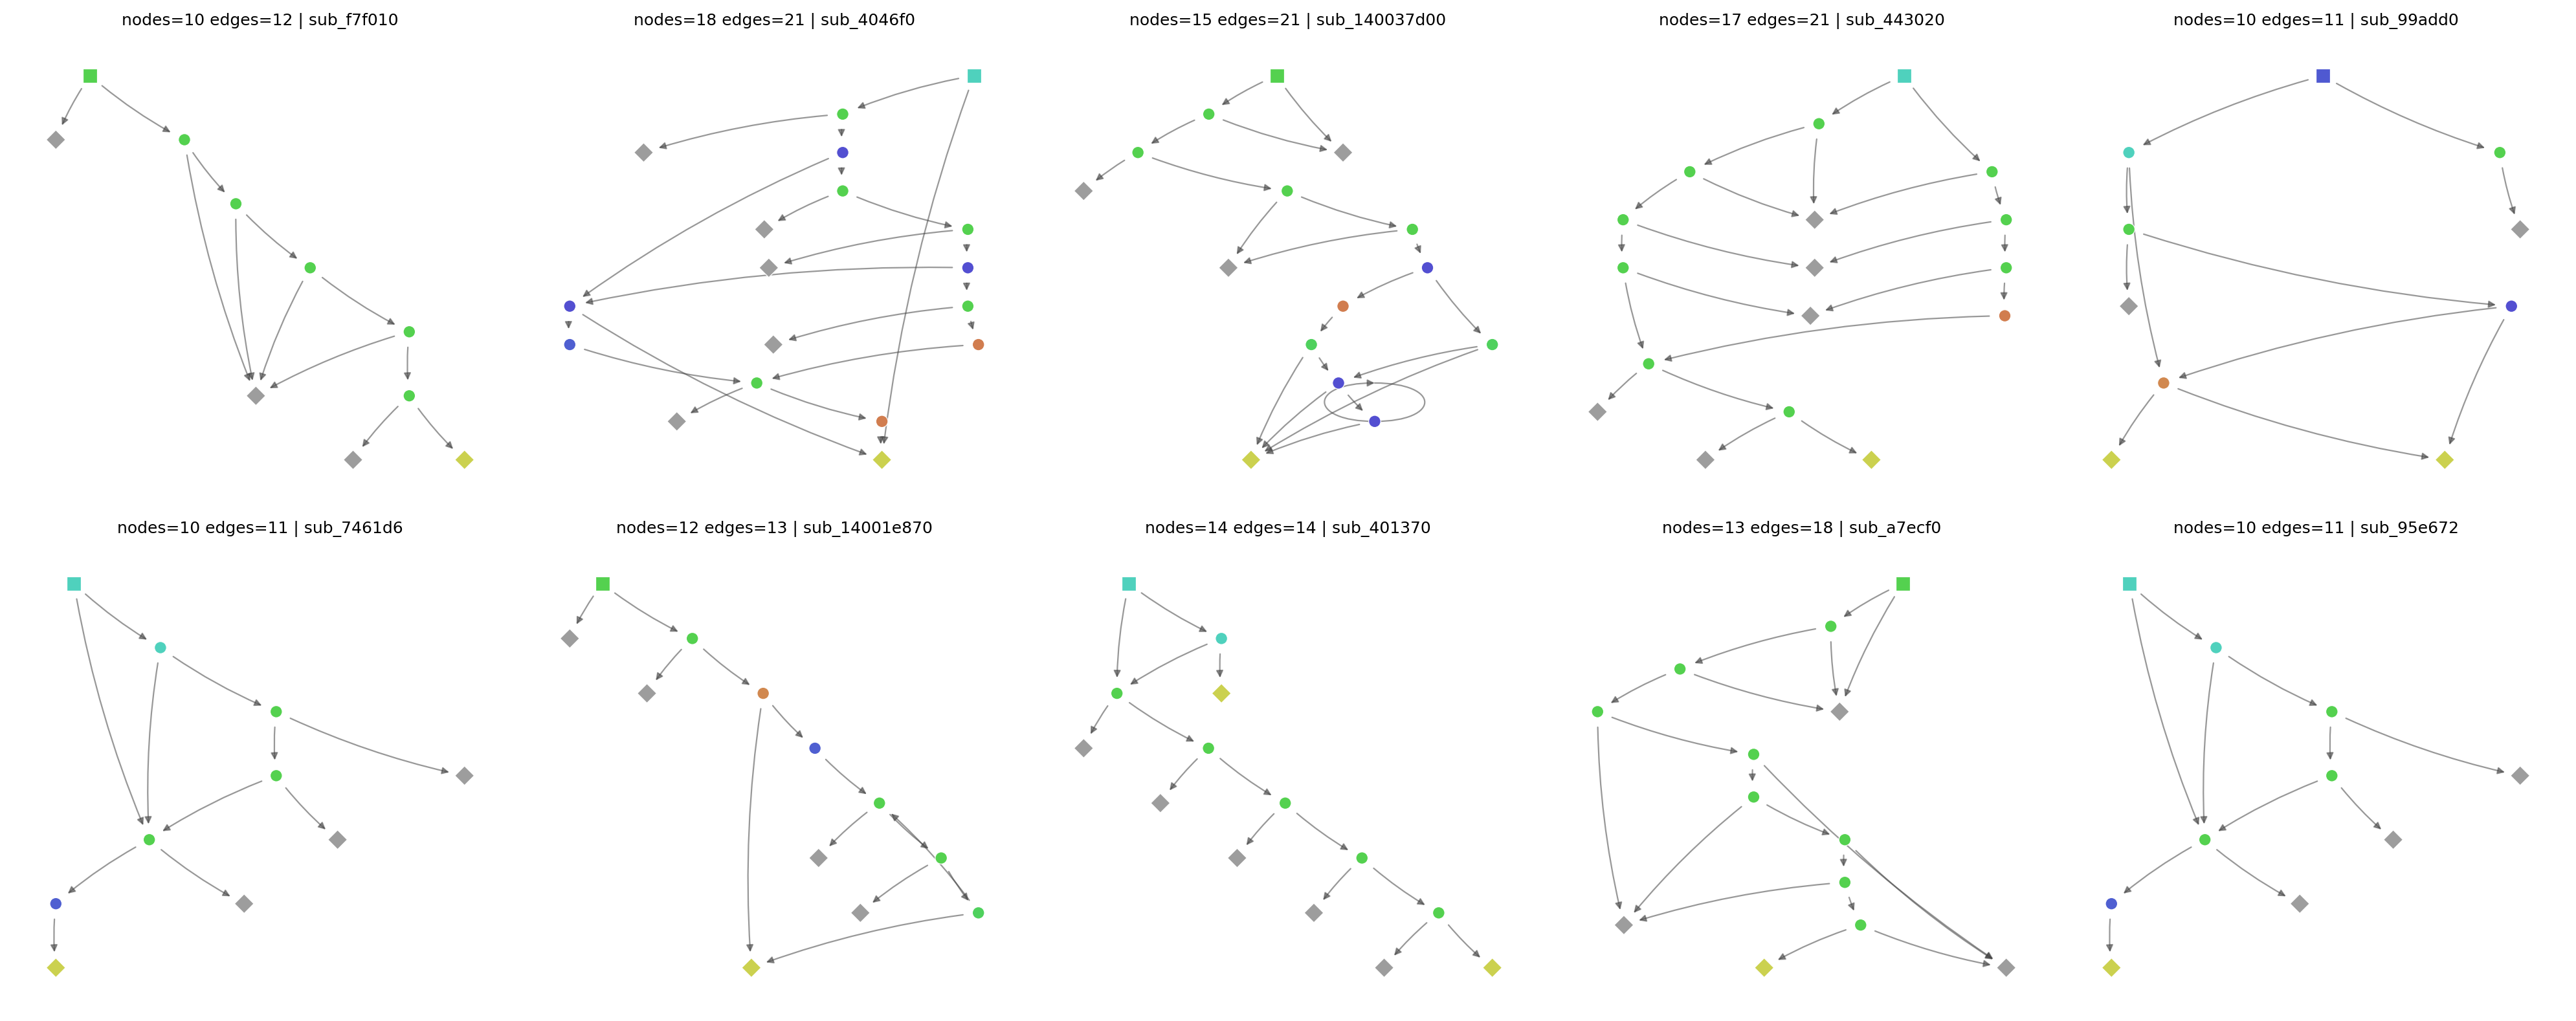

In [4]:
DATASET_PATH = Path(
    "/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/ControlFlowGraphsForMalware/processed_ml/balanced_mnemonic_networkx_graphs.pkl"
)

DEFAULT_CFG_EDGE_LABEL = "cfg_edge"

dataset_name = DATASET_PATH.stem
size = 500
min_num_nodes = 10
max_num_nodes = 20
USE_TARGETS = False
TARGET_MODE = "classification"


def normalize_cfg_graph(graph: nx.DiGraph) -> nx.DiGraph:
    normalized = nx.DiGraph()
    normalized.graph.update(graph.graph)
    for node, attrs in graph.nodes(data=True):
        node_attrs = dict(attrs)
        role = node_role(node_attrs)
        node_attrs["label"] = f"{role}:{mnemonic_label(node_attrs)}"
        normalized.add_node(node, **node_attrs)
    for u, v in graph.edges():
        normalized.add_edge(u, v, label=DEFAULT_CFG_EDGE_LABEL)
    return normalized


with DATASET_PATH.open("rb") as handle:
    all_graphs = pickle.load(handle)

candidate_graphs = [
    normalize_cfg_graph(graph)
    for graph in all_graphs
    if graph.is_directed()
    and min_num_nodes <= graph.number_of_nodes() <= max_num_nodes
    and graph.number_of_edges() > 0
]
random.Random(0).shuffle(candidate_graphs)
graphs = candidate_graphs[:size]
metadata = [dict(graph.graph) for graph in graphs]
edge_labels = sorted({attrs.get("label") for graph in graphs for _, _, attrs in graph.edges(data=True)})


def graph_target(graph):
    return graph.graph.get("binary_label", graph.graph.get("label"))
targets = [graph_target(graph) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"source_path: {DATASET_PATH}")
print(f"raw_graphs: {len(all_graphs)}")
print(f"filtered_graphs: {len(candidate_graphs)}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
print(f"all_directed: {all(graph.is_directed() for graph in graphs)}")
print(f"edge_labels: {edge_labels}")
print(f"nodes: min={min(g.number_of_nodes() for g in graphs)} median={np.median([g.number_of_nodes() for g in graphs]):.0f} max={max(g.number_of_nodes() for g in graphs)}")
print(f"edges: min={min(g.number_of_edges() for g in graphs)} median={np.median([g.number_of_edges() for g in graphs]):.0f} max={max(g.number_of_edges() for g in graphs)}")
if USE_TARGETS:
    print(f"target_mode: {TARGET_MODE}")
    print(f"targets: {sorted(set(targets))}")
else:
    print("targets disabled")

_ = display_graphs(graphs[:10], n_graphs_per_line=5)



In [5]:
from sklearn.linear_model import SGDRegressor, SGDClassifier

estimator_decomposition_function = add(neighborhood(radius=(1, 2)), path(number_of_edges=3))
vectorizer = AbstractGraphTransformer(
    nbits=14,
    decomposition_function=estimator_decomposition_function,
    return_dense=False,
    n_jobs=-1,
)

#==================================================================================================
feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=1),
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1, direction="weak"),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=1),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)
#==================================================================================================

classifier = RandomForestClassifier(
    random_state=0,
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
classifier = SGDClassifier(
    loss='log_loss',
    random_state=None,
)

regressor = SGDRegressor(
    loss='epsilon_insensitive',
    alpha=1e-4,
    max_iter=1000,
    tol=1e-3,
    random_state=None,
)
regressor = RandomForestRegressor(
    random_state=0,
    n_estimators=300,
    n_jobs=-1,
)

graph_classifier = GraphEstimator(
    transformer=vectorizer,
    estimator=classifier,
)
graph_regressor = GraphEstimator(
    transformer=vectorizer,
    estimator=regressor,
)

target_estimator = None
if USE_TARGETS:
    if TARGET_MODE == "classification":
        target_estimator = graph_classifier
    else:
        target_estimator = graph_regressor

generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=graph_classifier,
    target_estimator=target_estimator,
    target_estimator_mode=TARGET_MODE,
    decomposition_function=neighborhood(radius=1, direction="weak"),
    enforce_diversity=False,
    n_negative_per_positive=3,
    n_replicates=5,
    beam_size=1,
    max_restarts=4,
    fit_n_jobs=-1,
    fit_backend="loky",
    verbose=True,
    seed=0,
    require_single_connected_component=True,
)



In [6]:
%%time
repair_rng = random.Random()
repair_idx = repair_rng.randrange(len(graphs))
graph = graphs[repair_idx]
repair_target = targets[repair_idx] if USE_TARGETS else None

store_graphs = graphs[:repair_idx] + graphs[repair_idx + 1 :]
store_targets = None if targets is None else targets[:repair_idx] + targets[repair_idx + 1 :]

generator.store(store_graphs, targets=store_targets)
print(f"held_out_graph_idx = {repair_idx}")
print(f"stored_graphs = {len(generator.stored_graphs_)}")
print(f"held_out_removed_from_store = {len(store_graphs) == len(graphs) - 1 and graph not in store_graphs}")


held_out_graph_idx = 429
stored_graphs = 499
held_out_removed_from_store = True
CPU times: user 16.9 s, sys: 1.55 s, total: 18.4 s
Wall time: 51.6 s


## Directed CFG Repair Workflow

Select one stored control-flow `DiGraph` at random, perturb it by moving `k` directed edges,
then repair it with `EdgeGenerator.repair(...)` using the nearest stored directed CFGs as the local fitting set.


held_out_graph_idx = 429
repair_target = None
num_edges_to_perturb = 4
original_edges = 19
perturbed_edges = 19
original_directed = True
perturbed_directed = True


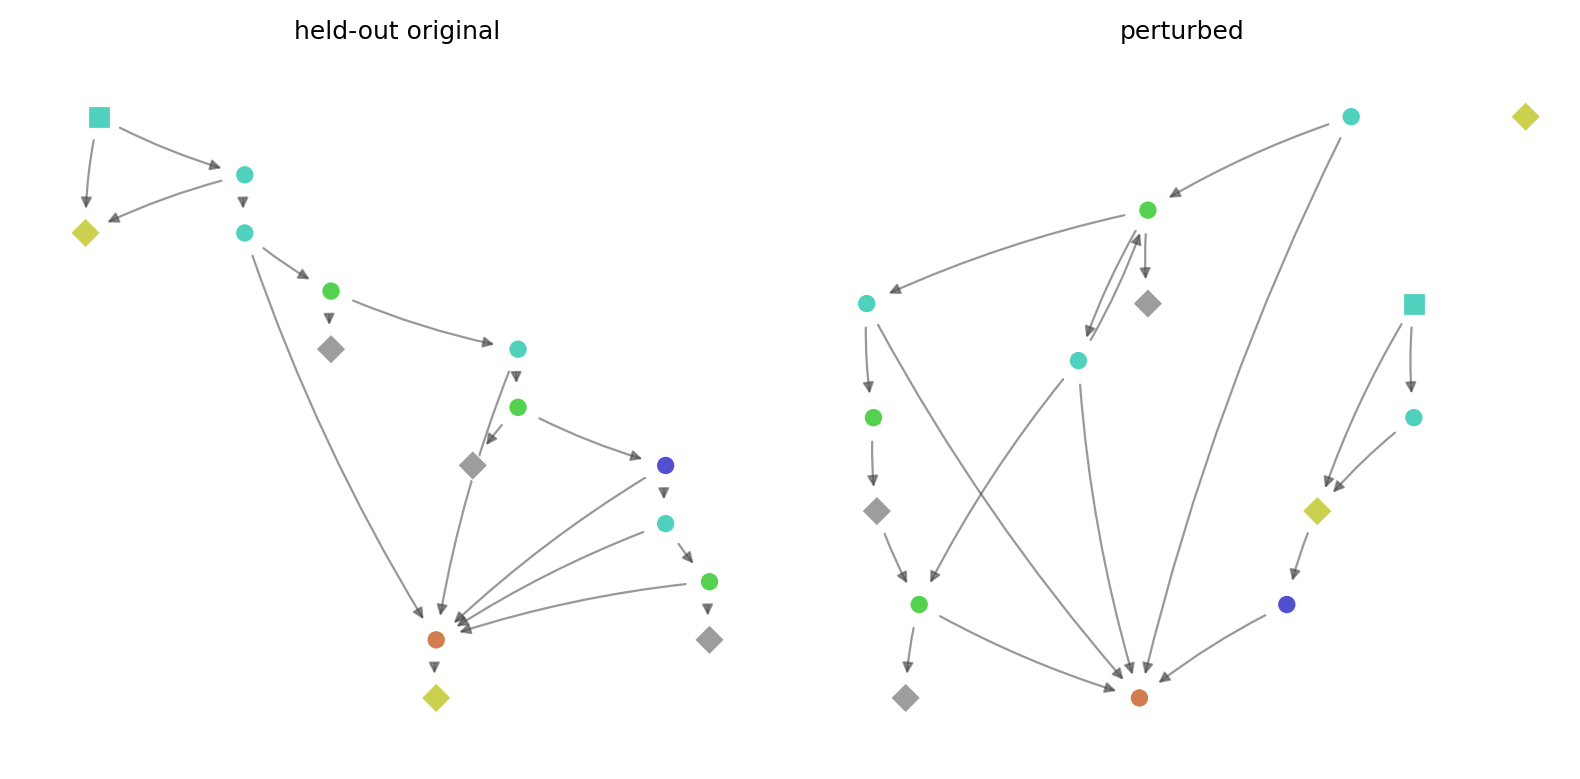

In [7]:
num_edges_to_perturb = 4
perturb_seed = 0


def move_random_edges(graph, k, *, seed=0):
    perturbed = graph.copy()
    rng = random.Random(seed)
    for _ in range(max(0, int(k))):
        neighbors = edge_neighbors(
            perturbed,
            n_samples=1,
            seed=rng.randrange(10**9),
        )
        if not neighbors:
            break
        perturbed = neighbors[0]
    return perturbed


perturbed_graph = move_random_edges(graph, num_edges_to_perturb, seed=perturb_seed)

print(f"held_out_graph_idx = {repair_idx}")
print(f"repair_target = {repair_target}")
print(f"num_edges_to_perturb = {num_edges_to_perturb}")
print(f"original_edges = {graph.number_of_edges()}")
print(f"perturbed_edges = {perturbed_graph.number_of_edges()}")
print(f"original_directed = {graph.is_directed()}")
print(f"perturbed_directed = {perturbed_graph.is_directed()}")
_ = display_graphs([graph, perturbed_graph], n_graphs_per_line=2, titles=["held-out original", "perturbed"])


[repair] query_index=None n_neighbors=10 neighbor_indices=[171, 311, 424, 413, 257, 226, 221, 381, 398, 151] neighbor_distances=[29.2233, 29.4618, 29.5296, 29.6479, 29.6816, 29.7993, 29.8496, 29.8664, 29.9333, 29.9833]


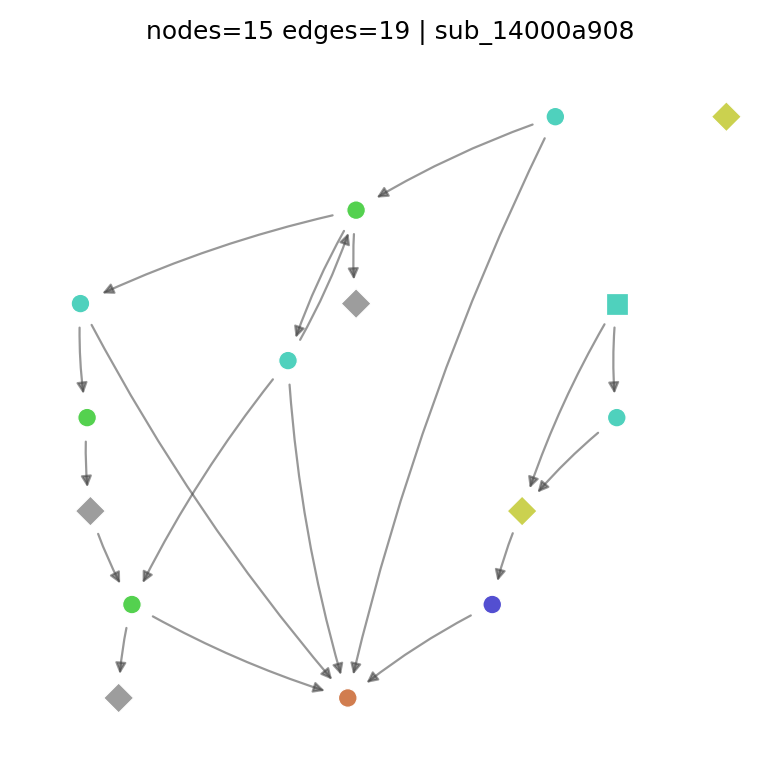

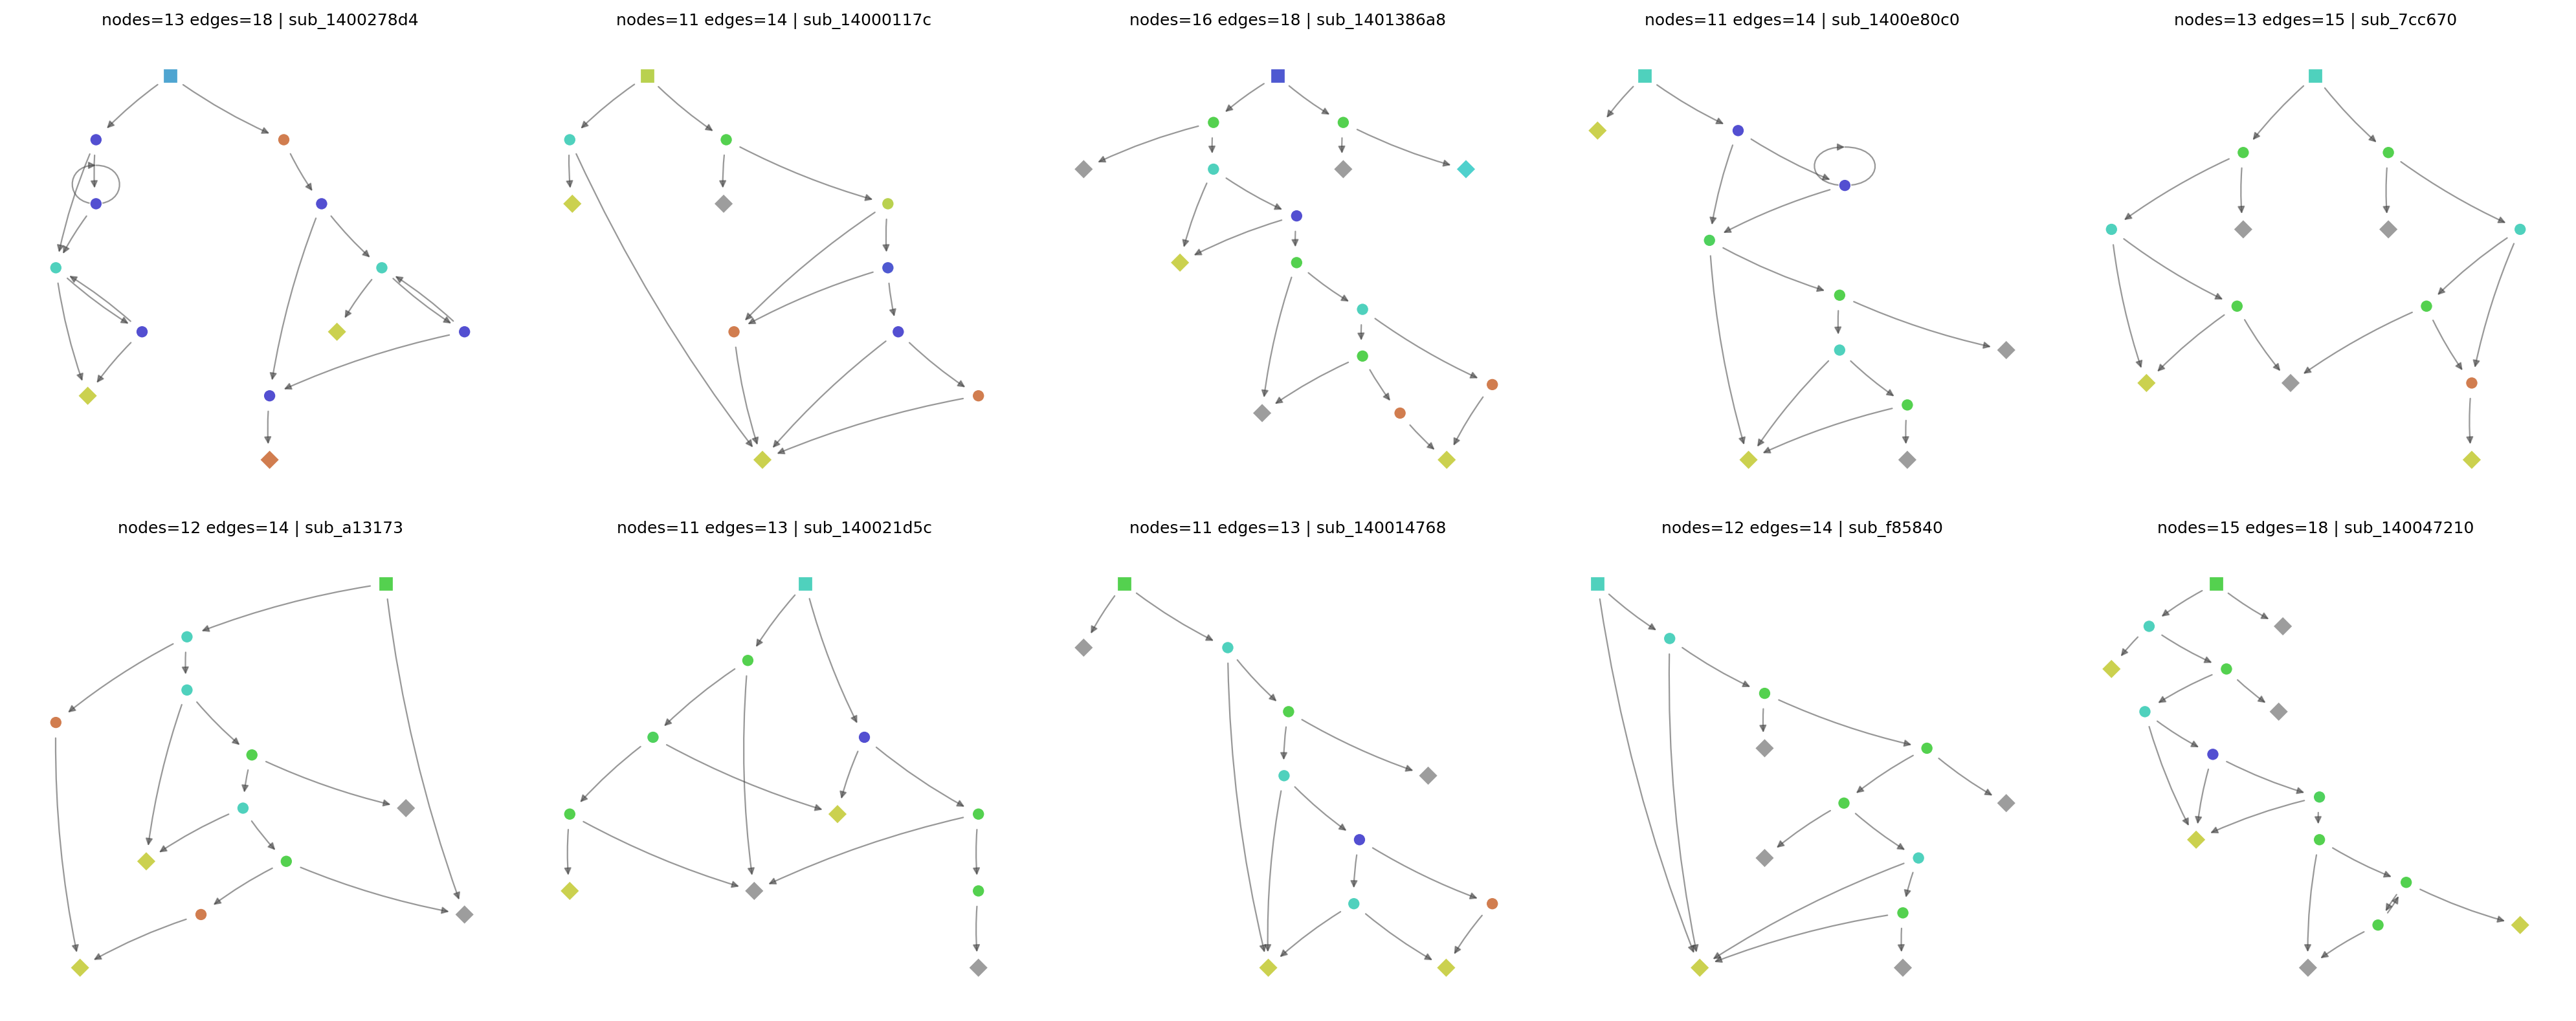

[fit] partial_feasibility_graphs=716 final_feasibility_graphs=10 positives=755 negatives=2115 dataset=2870 partial_time=0m 3.5s final_time=0m 0.2s
[fit] graph_estimator_graphs=2870 positive_labels=755 negative_labels=2115 time=0m 23.6s
[repair] attempt=1/4 start_edges=16 target_edges=19 removed_edges=[(1, 11), (10, 13), (12, 5)]


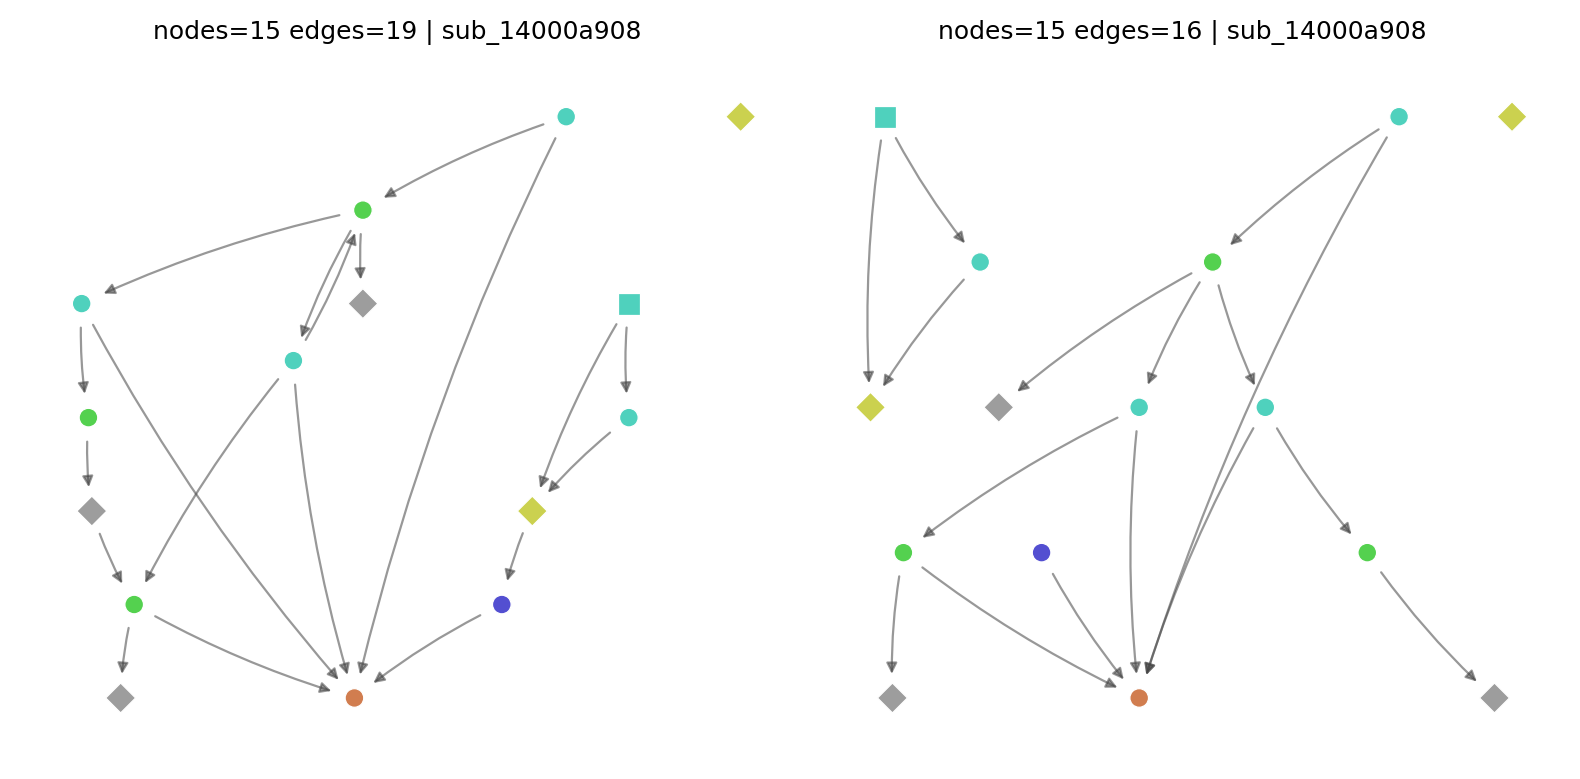

[graph 0] start start_edges=16 target_edges=19 remaining_edges=3


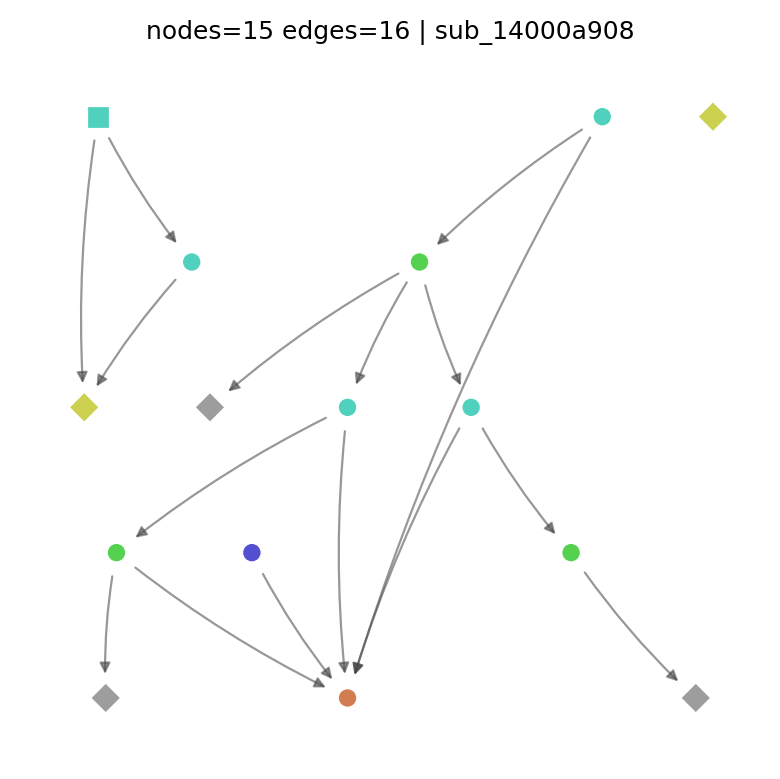

[graph 0] fallback=1/5 beam_limit=1
[graph 0] fallback=1/5 depth=1 remaining_edges=2 step_time=0m 12.2s eta=0m 24.3s
generated=194 partial_feasible=77 viable=77 retained=1 tried=194 partial_infeasible=117
best_score=0.000
beam_limit=1


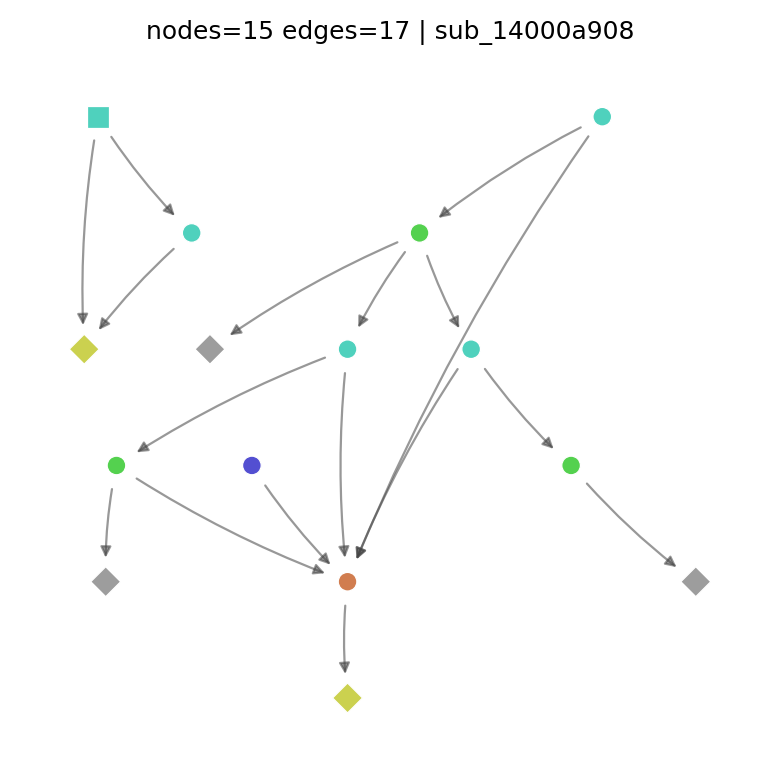

[graph 0] fallback=1/5 depth=2 remaining_edges=1 step_time=0m 11.5s eta=0m 11.5s
generated=193 partial_feasible=76 viable=76 retained=1 tried=387 partial_infeasible=117
best_score=0.000
beam_limit=1


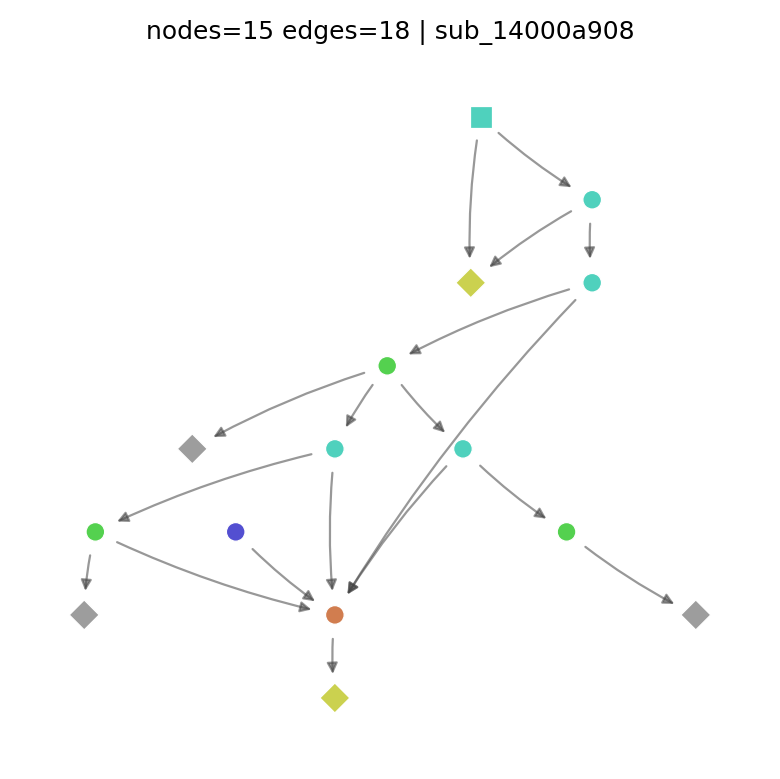

[graph 0] fallback=1/5 depth=3 remaining_edges=0 step_time=0m 15.0s eta=0m 0.0s
generated=192 partial_feasible=74 viable=0 retained=0 tried=579 partial_infeasible=118 completion_infeasible=57 final_infeasible=17
best_score=None
beam_limit=1
[graph 0] BACKTRACK no feasible candidates remain; 4 fallback phase(s) left
[graph 0] fallback=1/4 rollback_steps=2 surgical_repairs=1 to_depth=0 beam_limit=2
[graph 0] surgical_removed_edges=['(11, 4),(2, 3)']
[graph 0] fallback=2/5 beam_limit=2
[graph 0] fallback=2/5 depth=1 remaining_edges=2 step_time=0m 13.8s eta=0m 27.7s
generated=194 partial_feasible=78 viable=78 retained=2 tried=773 partial_infeasible=116
best_score=0.000 best_selection_score=-0.172 best_repulsion=0.860
repulsion_lambda=0.200 beam_limit=2


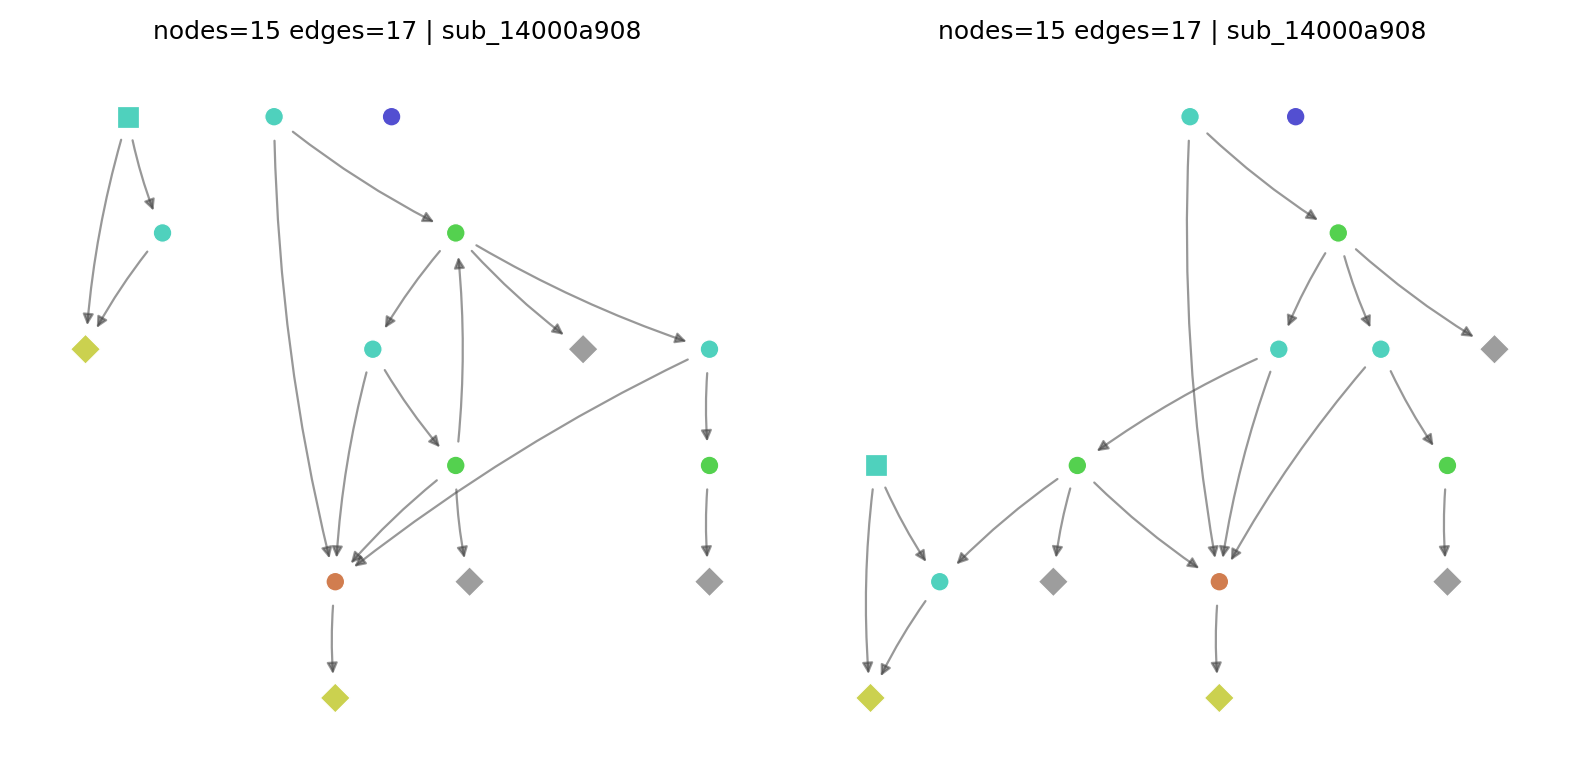

[graph 0] fallback=2/5 depth=2 remaining_edges=1 step_time=0m 31.0s eta=0m 31.0s
generated=386 partial_feasible=152 viable=92 retained=2 tried=1159 partial_infeasible=234 completion_infeasible=60
best_score=0.000 best_selection_score=-0.153 best_repulsion=0.767
repulsion_lambda=0.200 beam_limit=2


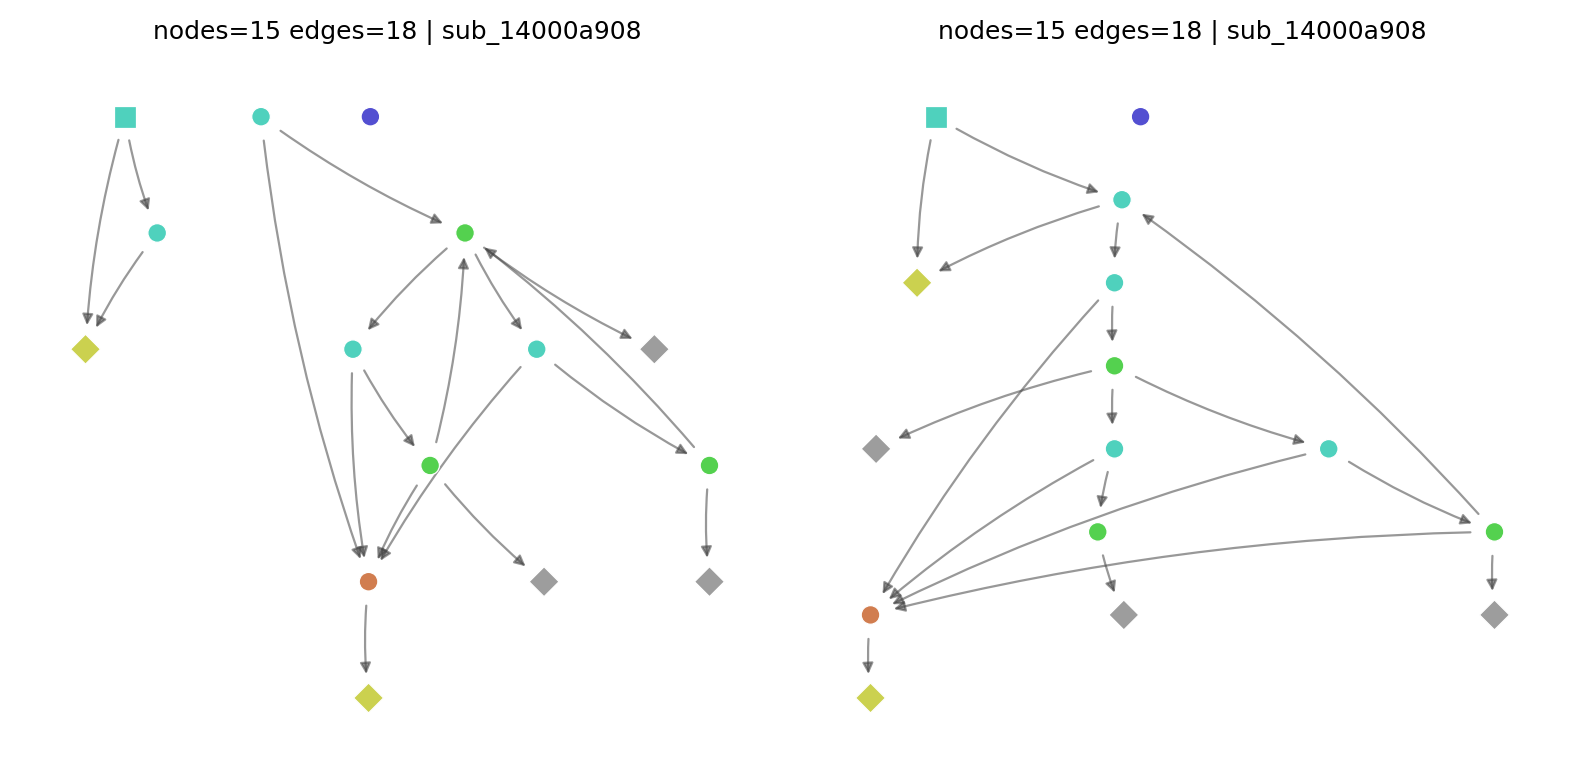

[graph 0] fallback=2/5 depth=3 remaining_edges=0 step_time=0m 32.9s eta=0m 0.0s
generated=384 partial_feasible=148 viable=0 retained=0 tried=1543 partial_infeasible=236 completion_infeasible=131 final_infeasible=17
best_score=None
beam_limit=2
[graph 0] BACKTRACK no feasible candidates remain; 3 fallback phase(s) left
[graph 0] fallback=2/4 rollback_steps=4 surgical_repairs=1 to_depth=0 beam_limit=3
[graph 0] surgical_removed_edges=['(12, 13),(9, 5),(8, 9),(5, 8)']
[graph 0] fallback=3/5 beam_limit=3
[graph 0] fallback=3/5 depth=1 remaining_edges=4 step_time=0m 14.0s eta=0m 56.2s
generated=196 partial_feasible=82 viable=82 retained=3 tried=1739 partial_infeasible=114
best_score=0.000 best_selection_score=-0.229 best_repulsion=0.764
repulsion_lambda=0.300 beam_limit=3


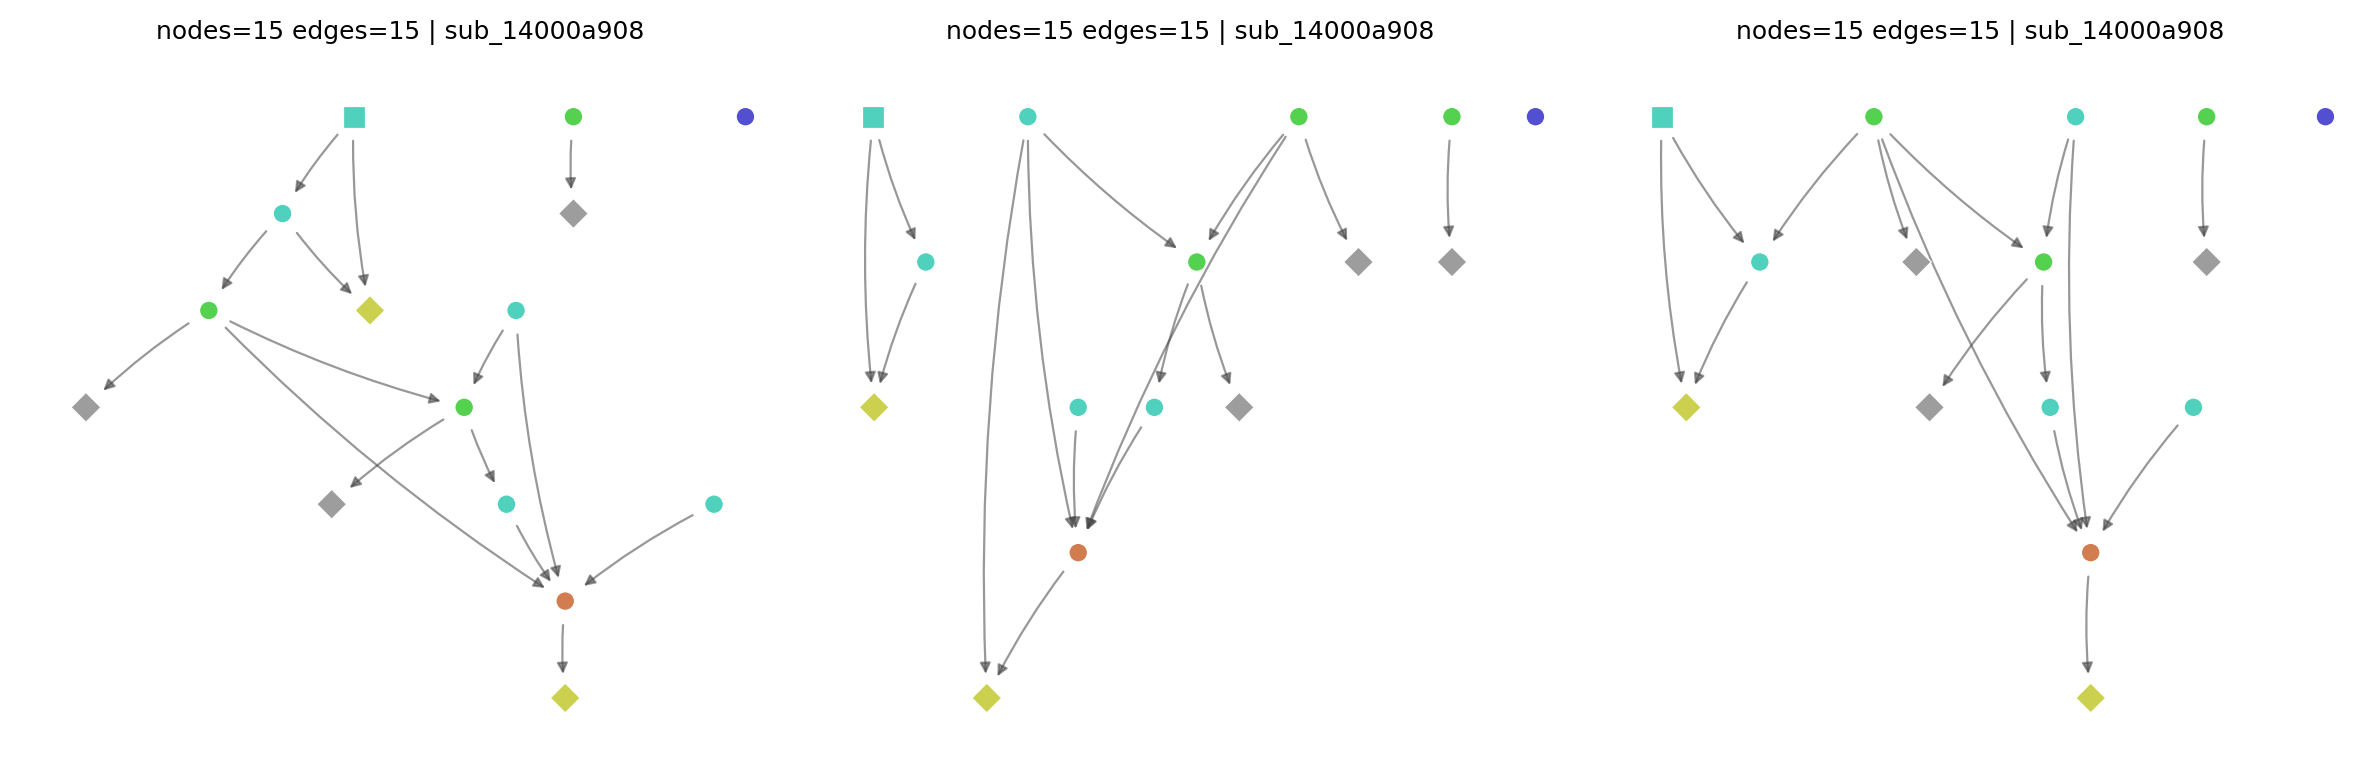

[graph 0] fallback=3/5 depth=2 remaining_edges=3 step_time=0m 38.6s eta=1m 55.7s
generated=585 partial_feasible=241 viable=241 retained=3 tried=2324 partial_infeasible=344
best_score=0.000 best_selection_score=-0.222 best_repulsion=0.740
repulsion_lambda=0.300 beam_limit=3


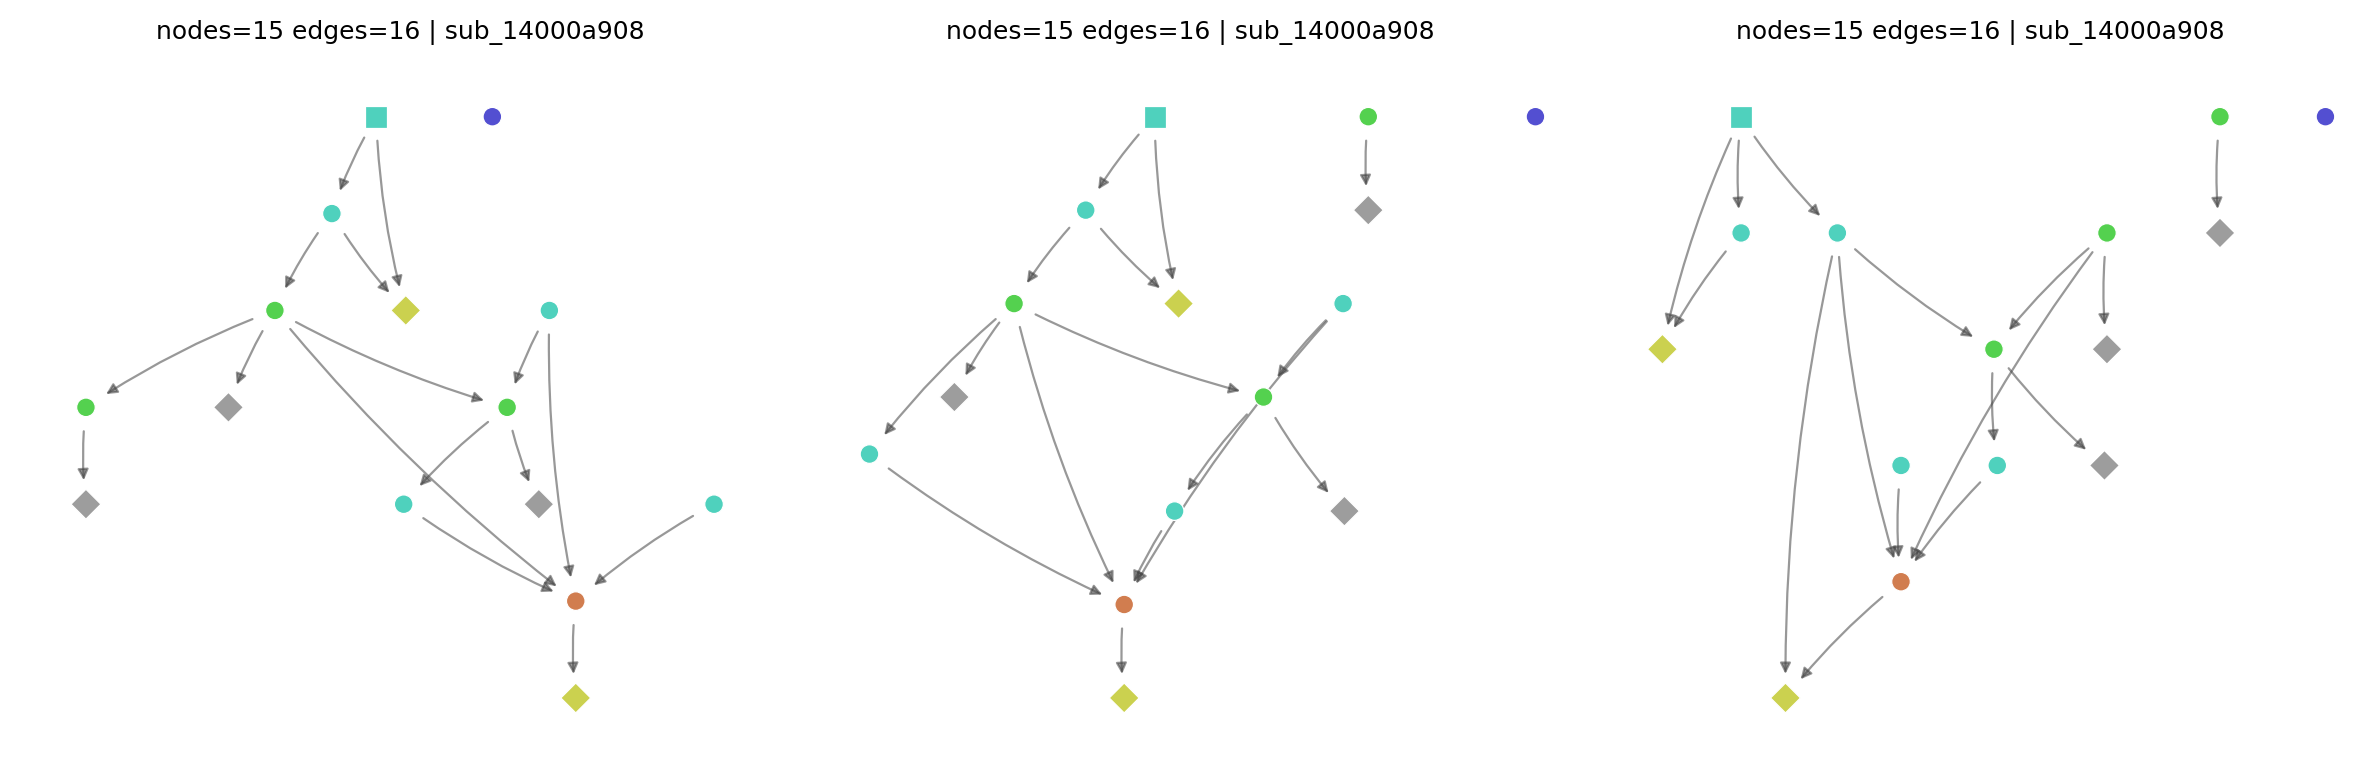

[graph 0] fallback=3/5 depth=3 remaining_edges=2 step_time=0m 43.6s eta=1m 27.1s
generated=582 partial_feasible=236 viable=236 retained=3 tried=2906 partial_infeasible=346
best_score=0.000 best_selection_score=-0.212 best_repulsion=0.707
repulsion_lambda=0.300 beam_limit=3


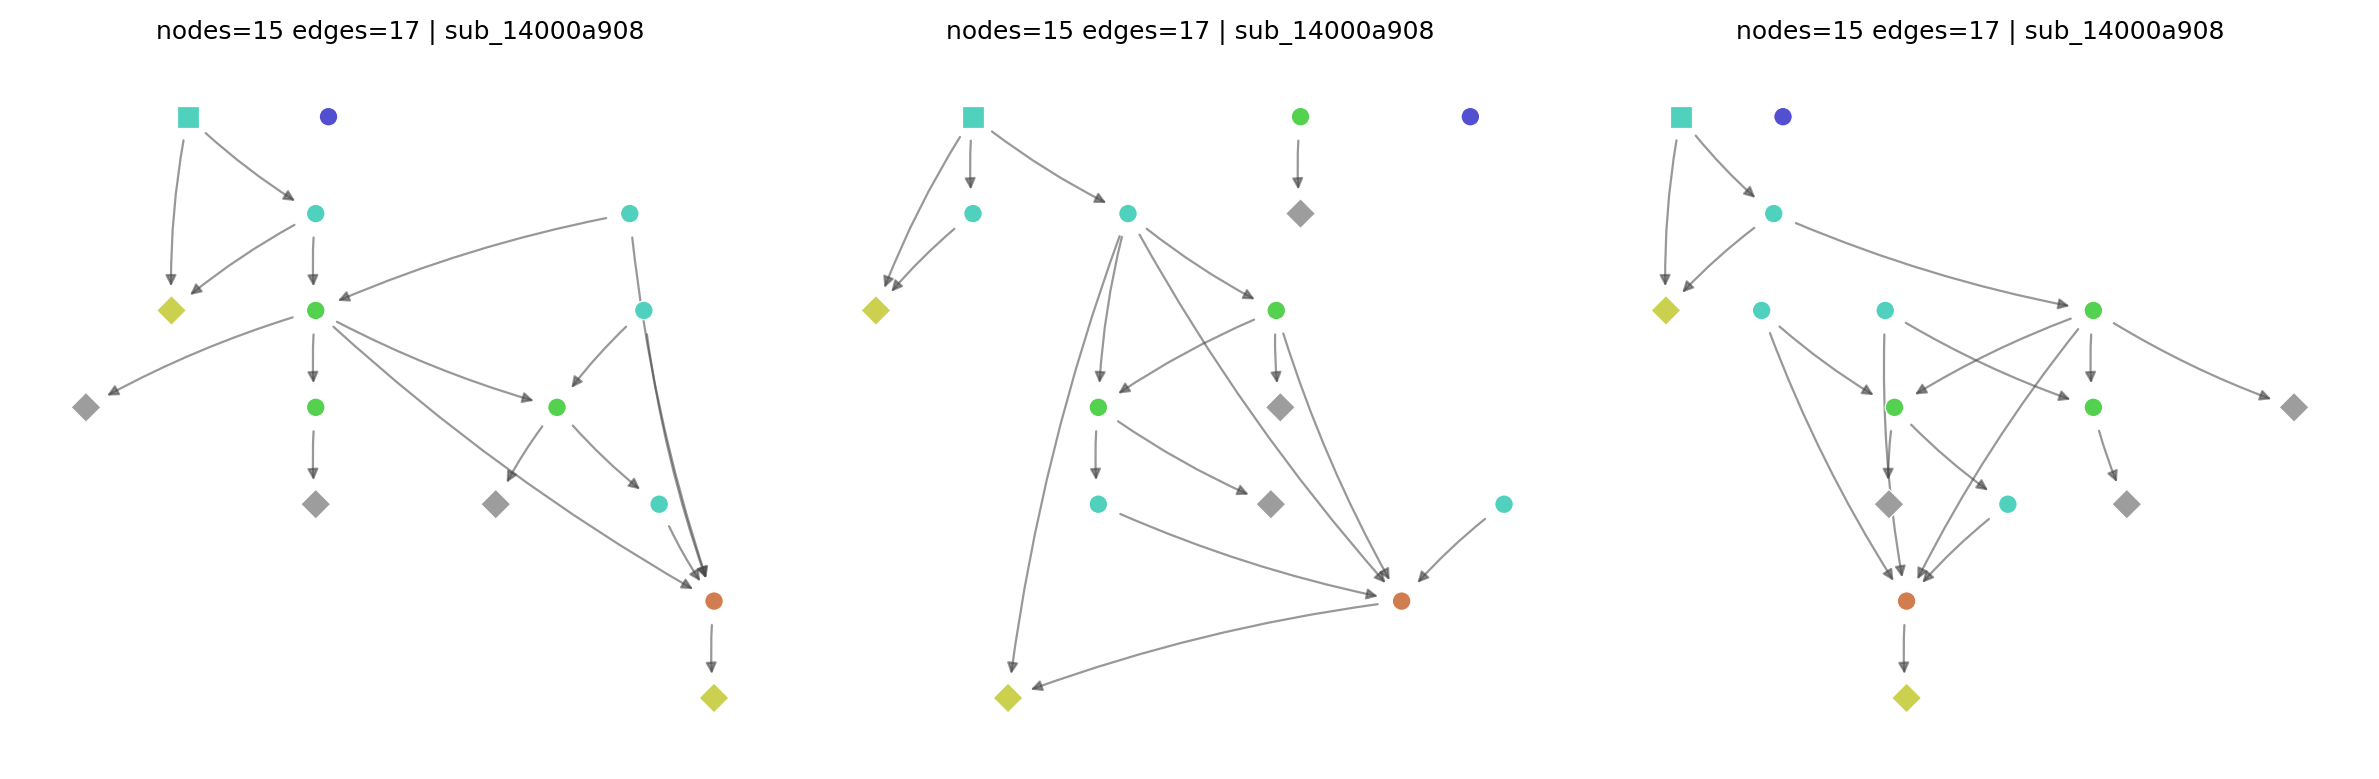

[graph 0] fallback=3/5 depth=4 remaining_edges=1 step_time=0m 46.8s eta=0m 46.8s
generated=579 partial_feasible=230 viable=196 retained=3 tried=3485 partial_infeasible=349 completion_infeasible=34
best_score=0.000 best_selection_score=-0.201 best_repulsion=0.669
repulsion_lambda=0.300 beam_limit=3


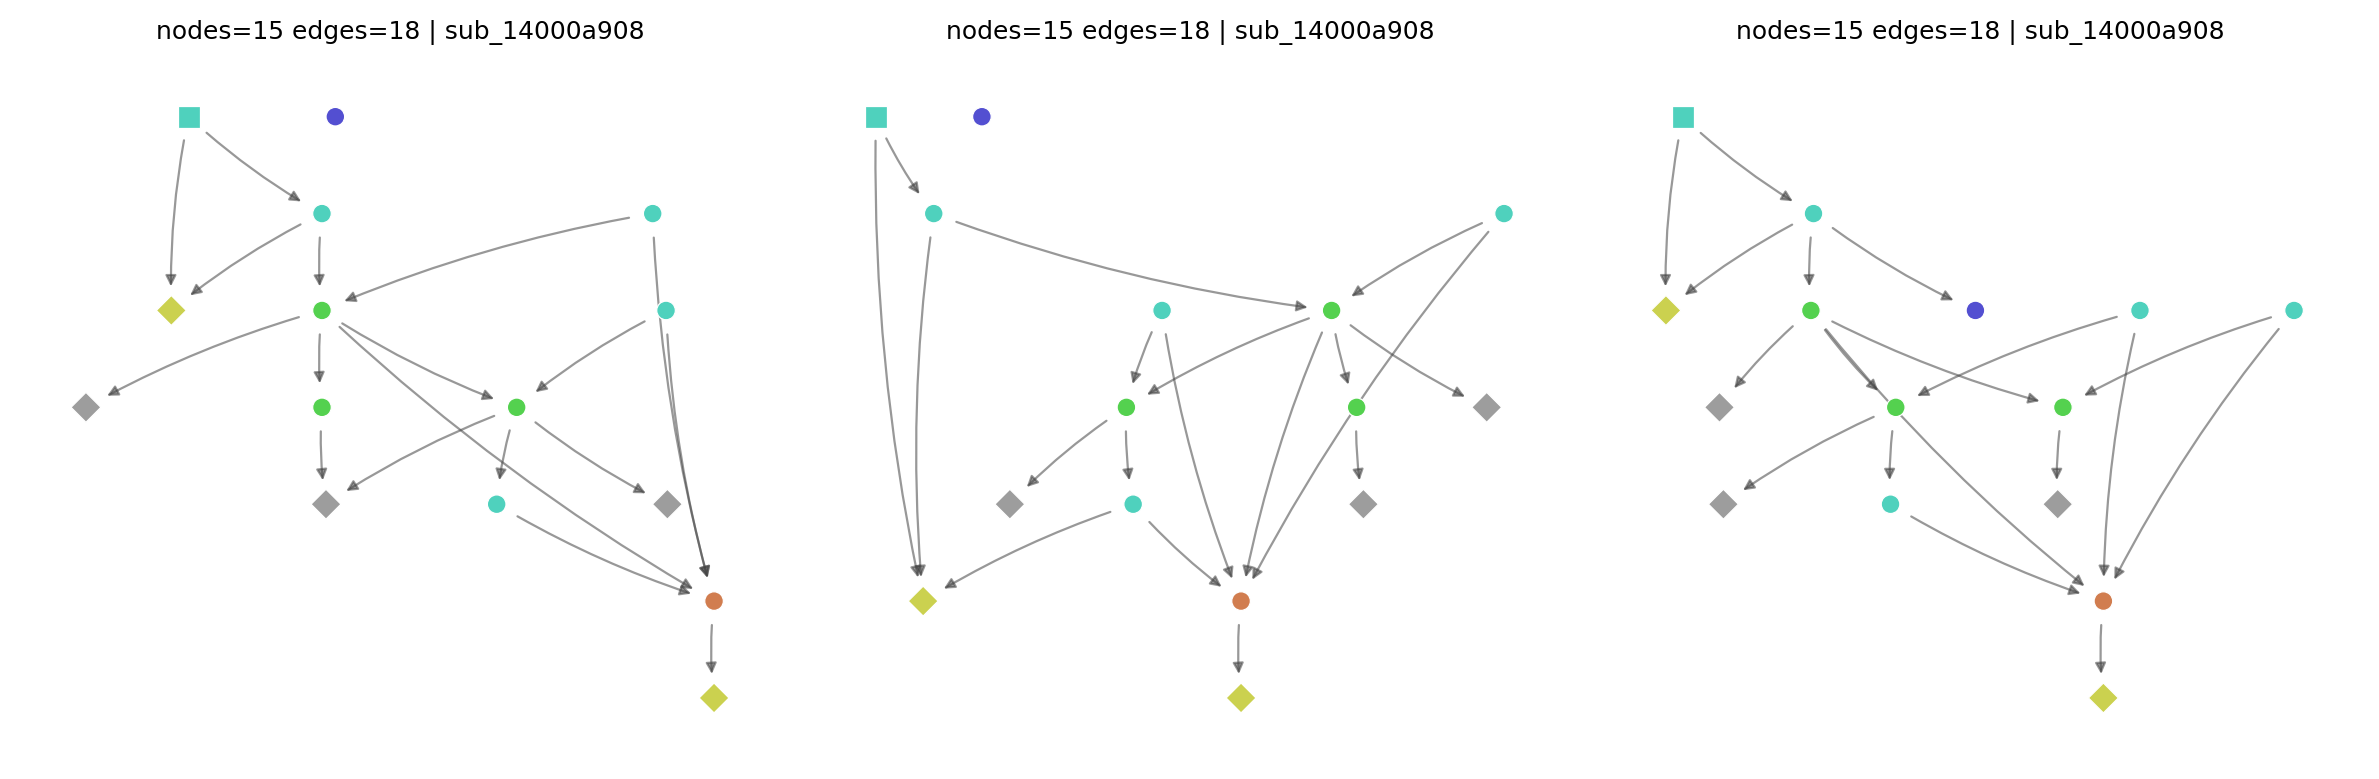

[graph 0] fallback=3/5 depth=5 remaining_edges=0 step_time=0m 46.2s eta=0m 0.0s
generated=576 partial_feasible=225 viable=0 retained=0 tried=4061 partial_infeasible=351 completion_infeasible=207 final_infeasible=18
best_score=None
beam_limit=3
[graph 0] BACKTRACK no feasible candidates remain; 2 fallback phase(s) left
[graph 0] fallback=3/4 rollback_steps=8 surgical_repairs=1 to_depth=0 beam_limit=4
[graph 0] surgical_removed_edges=['(13, 5),(5, 10),(8, 13),(13, 9),(2, 13),(4, 6),(13, 14),(13, 4)']
[graph 0] fallback=4/5 beam_limit=4
[graph 0] fallback=4/5 depth=1 remaining_edges=8 step_time=0m 11.8s eta=1m 34.1s
generated=200 partial_feasible=87 viable=87 retained=4 tried=4261 partial_infeasible=113
best_score=0.000 best_selection_score=-0.356 best_repulsion=0.790
repulsion_lambda=0.450 beam_limit=4


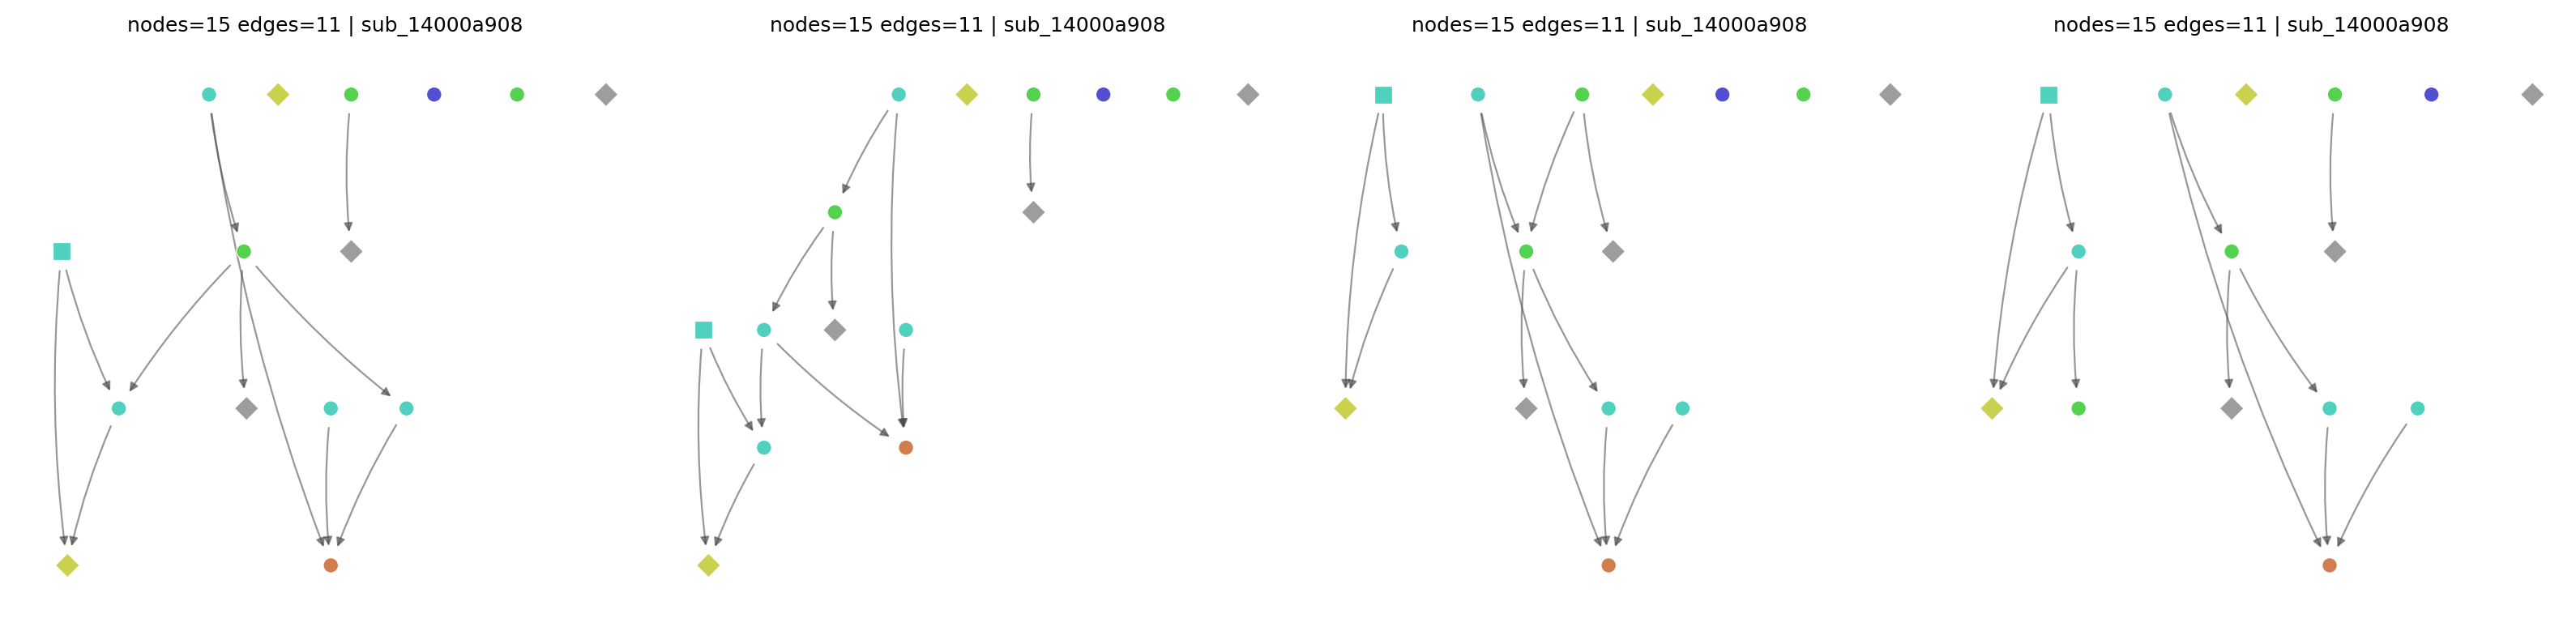

[graph 0] fallback=4/5 depth=2 remaining_edges=7 step_time=0m 46.4s eta=5m 24.8s
generated=796 partial_feasible=340 viable=340 retained=4 tried=5057 partial_infeasible=456
best_score=0.000 best_selection_score=-0.337 best_repulsion=0.748
repulsion_lambda=0.450 beam_limit=4


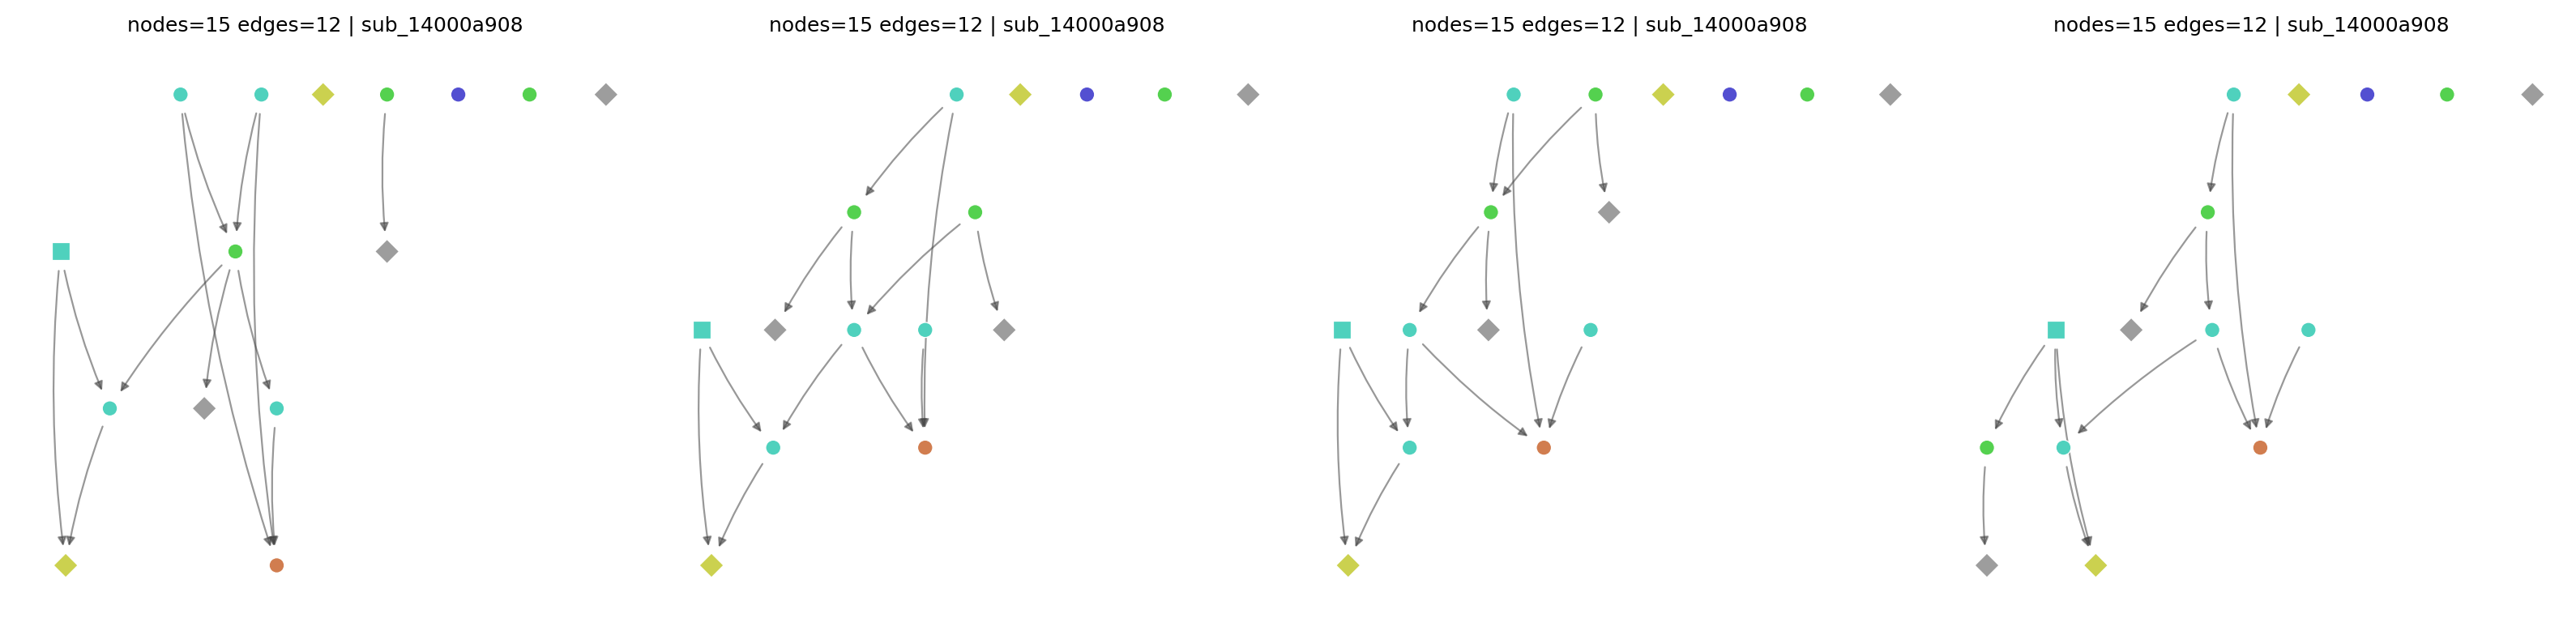

[graph 0] fallback=4/5 depth=3 remaining_edges=6 step_time=0m 52.5s eta=5m 14.8s
generated=792 partial_feasible=333 viable=333 retained=4 tried=5849 partial_infeasible=459
best_score=0.000 best_selection_score=-0.317 best_repulsion=0.705
repulsion_lambda=0.450 beam_limit=4


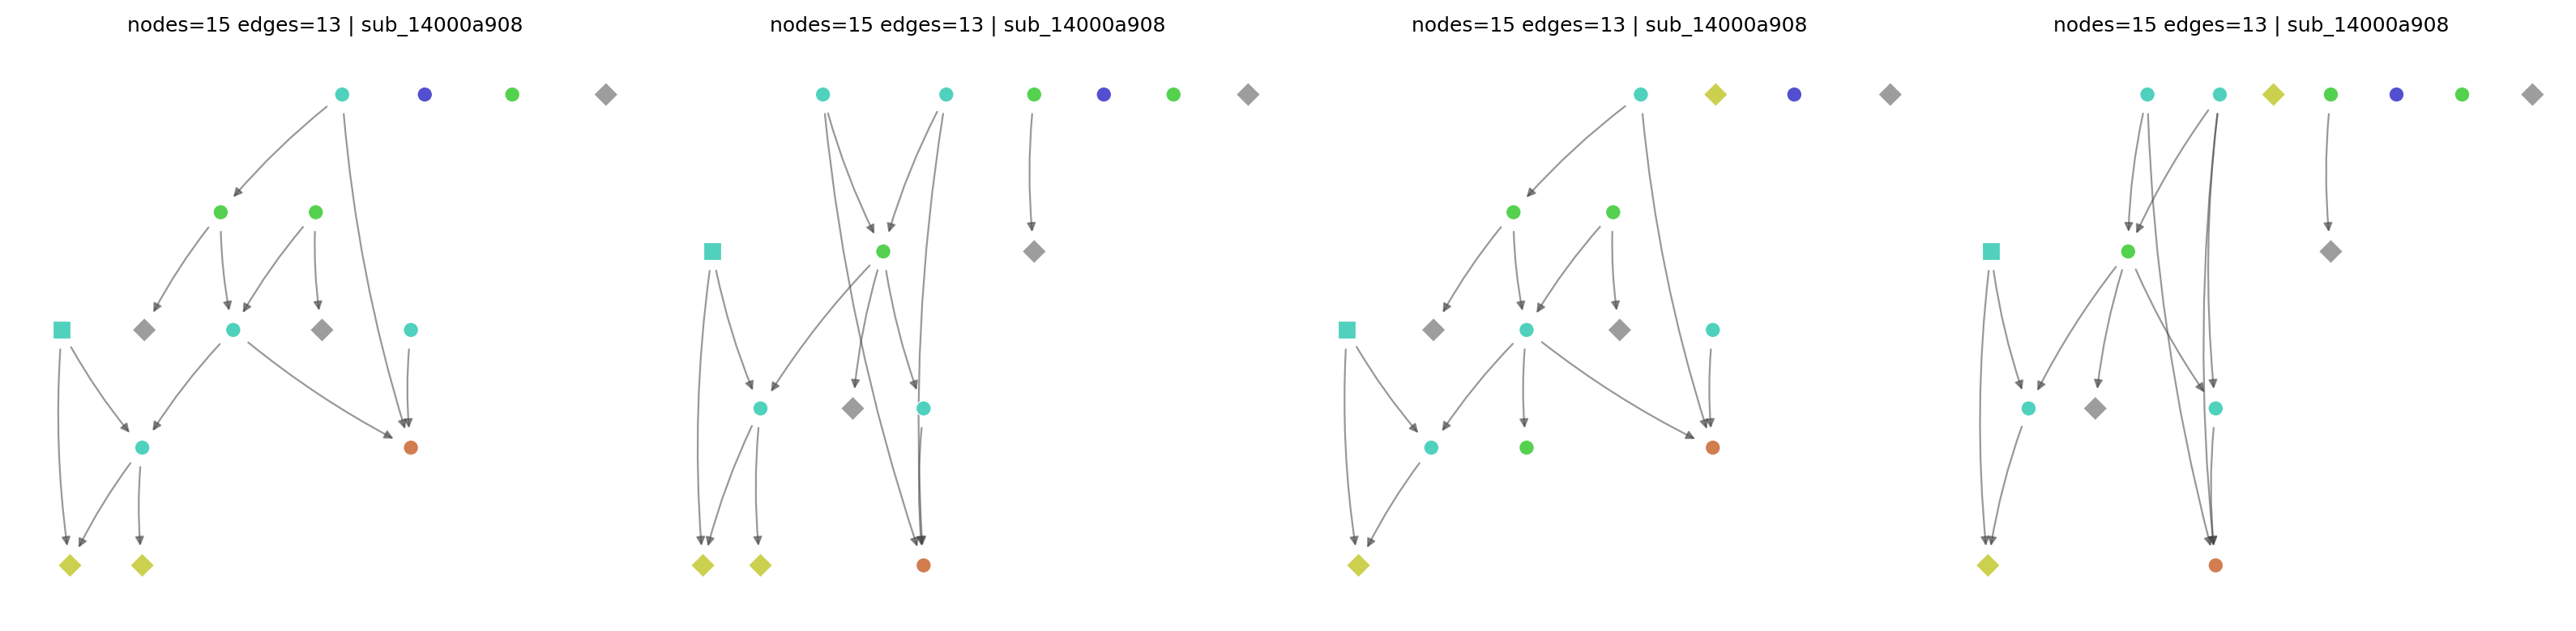

[graph 0] fallback=4/5 depth=4 remaining_edges=5 step_time=0m 56.4s eta=4m 42.2s
generated=788 partial_feasible=326 viable=326 retained=4 tried=6637 partial_infeasible=462
best_score=0.000 best_selection_score=-0.293 best_repulsion=0.652
repulsion_lambda=0.450 beam_limit=4


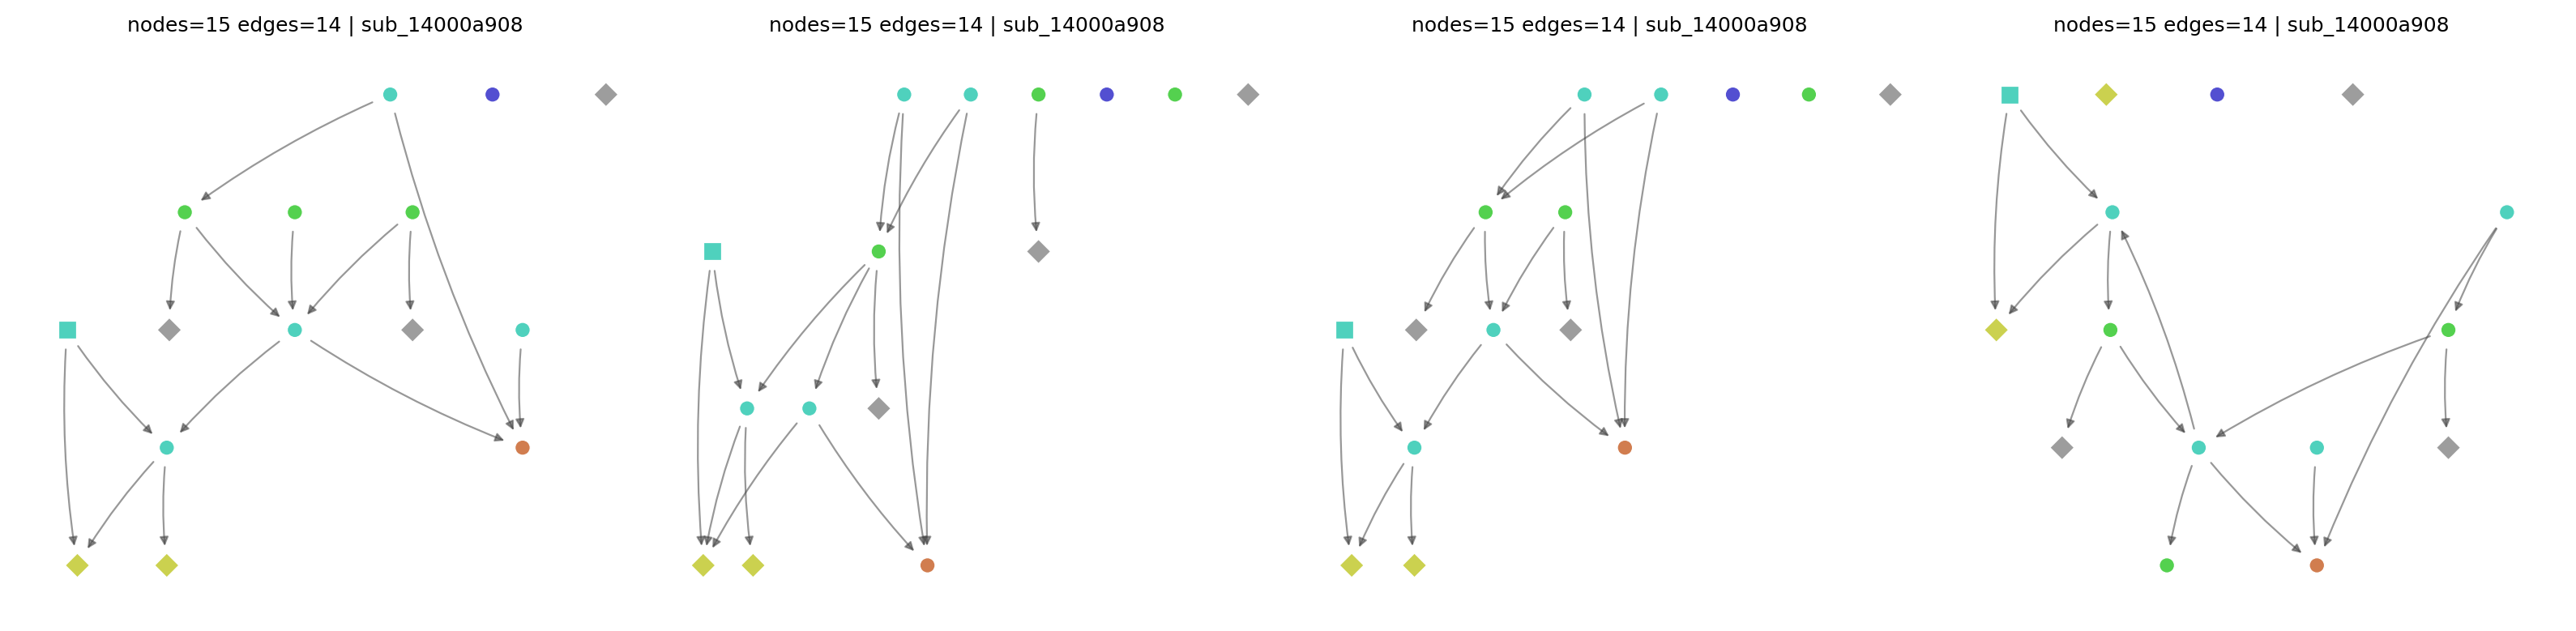

[graph 0] fallback=4/5 depth=5 remaining_edges=4 step_time=1m 24.6s eta=5m 38.6s
generated=784 partial_feasible=320 viable=320 retained=4 tried=7421 partial_infeasible=464
best_score=0.000 best_selection_score=-0.286 best_repulsion=0.635
repulsion_lambda=0.450 beam_limit=4


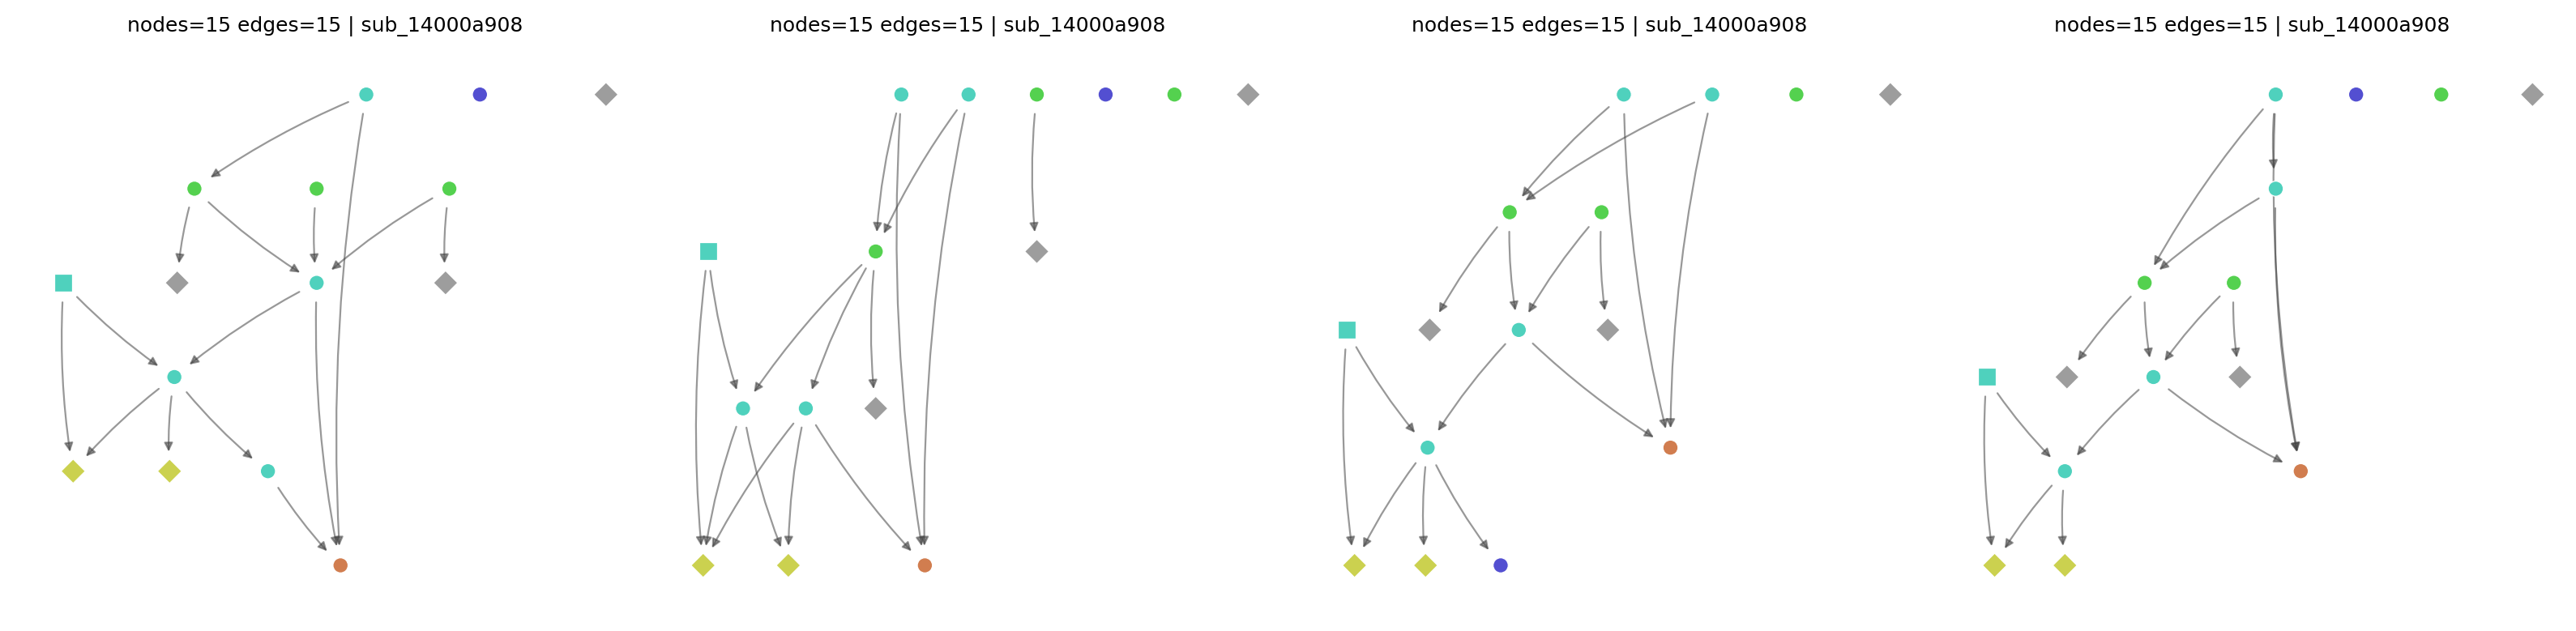

[graph 0] fallback=4/5 depth=6 remaining_edges=3 step_time=2m 17.7s eta=6m 53.0s
generated=780 partial_feasible=315 viable=304 retained=4 tried=8201 partial_infeasible=465 completion_infeasible=11
best_score=0.037 best_selection_score=-0.240 best_repulsion=0.616
repulsion_lambda=0.450 beam_limit=4


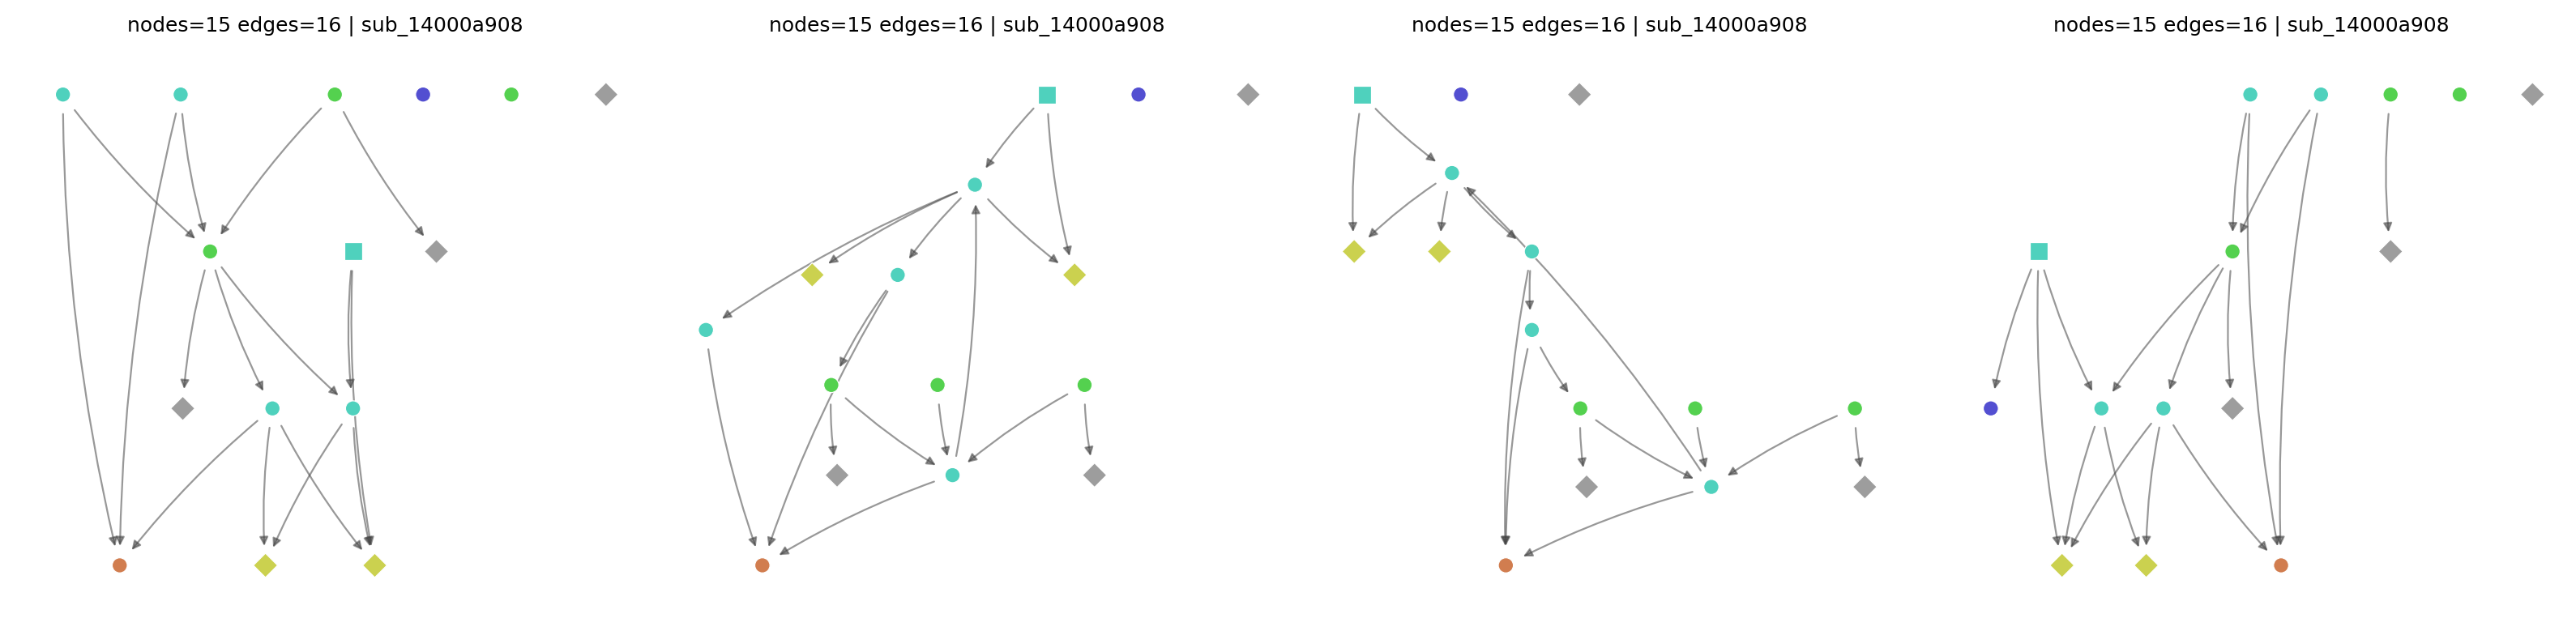

In [ ]:
%%time
graph_image_size = 4
n_neighbors = 10
repair_path = generator.repair(
    perturbed_graph,
    n_neighbors=n_neighbors,
    target=repair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=5, figsize_per_graph=(graph_image_size, graph_image_size), **kwargs),
)

print(f"repair_path_length = {len(repair_path)}")
if len(repair_path) > 0:
    print(f"final_n_edges = {repair_path[-1].number_of_edges()}")
    display_graphs(repair_path, n_graphs_per_line=5, figsize_per_graph=(graph_image_size, graph_image_size))
    print("Original and perturbed graphs:")
    display_graphs([graph, perturbed_graph], n_graphs_per_line=2, figsize_per_graph=(graph_image_size, graph_image_size), titles=["original", "perturbed"])
    print("Repaired graph:")
    display_graphs([repair_path[-1]], n_graphs_per_line=1, figsize_per_graph=(graph_image_size, graph_image_size), titles=["repaired"])
    print("Repair training set:")
    display_graphs(generator.last_repair_training_graphs_, n_graphs_per_line=5, figsize_per_graph=(graph_image_size, graph_image_size))


---
